# Processing 3.2 - LNs Annotation

## Introduction

Here the clustering and annotation for the visium data from LNs is performed.

In [1]:
setwd(here::here())

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(patchwork)
library(colorBlindness)
library(HDF5Array)
library(SpatialExperiment)
library(scran)
library(scuttle)
library(igraph)
library(ggspavis)
library(pheatmap)
library(lisi)
library(dittoSeq)
library(scater)
library(svglite)

here() starts at /home/groups/singlecell/cvicente/SP-COVID/visium/0-processing

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SparseArray

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:lubridate’:

    as.difftime


The following object is 

## Load data

In [3]:
spe <- loadHDF5SummarizedExperiment(
  dir = "out/2-processed_ln_spe" %>%
    glue::glue() %>%
    here::here()
)

spe

class: SpatialExperiment 
dim: 30450 11641 
metadata(0):
assays(2): counts logcounts
rownames(30450): ENSG00000238009 ENSG00000241860 ... SCoV2_ORF10
  SCoV2_UTR3
rowData names(5): symbol subsets_mito subsets_ribo subsets_SCoV2
  gene_name
colnames(11641): AAACAAGTATCTCCCA-1 AAACAATCTACTAGCA-1 ...
  TTGTTTCACATCCAGG-1 TTGTTTGTGTAAATTC-1
colData names(39): in_tissue array_row ... Leiden_res_0.5 lisi_study_id
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

## Clustering

We will perform graph-based clustering on the data using the Leiden community detection algorithm. We will use the  batch-corrected coordinates from Harmony integration to ensure clustering is not driven by technical variation between samples. To determine the optimal clustering granularity, we are going to test multiple resolution parameters.

In [4]:
set.seed(123)
g <- buildSNNGraph(spe, use.dimred = "HARMONY", type = "jaccard", k = 20)

resolutions <- c(0.55, 0.6, 0.75, 0.8)

results <- list()

for (res in resolutions) {
    set.seed(123)
    k <- cluster_leiden(g, objective_function = "modularity", resolution = res)
  
    cluster_col <- paste0("Leiden_res_", res)
    spe[[cluster_col]] <- factor(k$membership)
  
      results[[as.character(res)]] <- list(
          resolution = res,
          n_clusters = length(unique(k$membership)),
          cluster_sizes = table(k$membership),
          modularity = modularity(g, k$membership))
}

for (result in results) {
    cat("Resolution: ", result$resolution, "\n")
    cat("Nº clusters: ", result$n_clusters, "\n")
    cat("Spots per cluster: ", result$cluster_sizes, "\n", "\n")
}

Resolution:  0.55 
Nº clusters:  5 
Spots per cluster:  1670 1836 2665 2897 2573 
 
Resolution:  0.6 
Nº clusters:  6 
Spots per cluster:  1721 1805 2656 2871 894 1694 
 
Resolution:  0.75 
Nº clusters:  8 
Spots per cluster:  1618 1661 1538 1282 692 881 2306 1663 
 
Resolution:  0.8 
Nº clusters:  9 
Spots per cluster:  1597 1658 1471 54 1316 693 893 2298 1661 
 


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale f

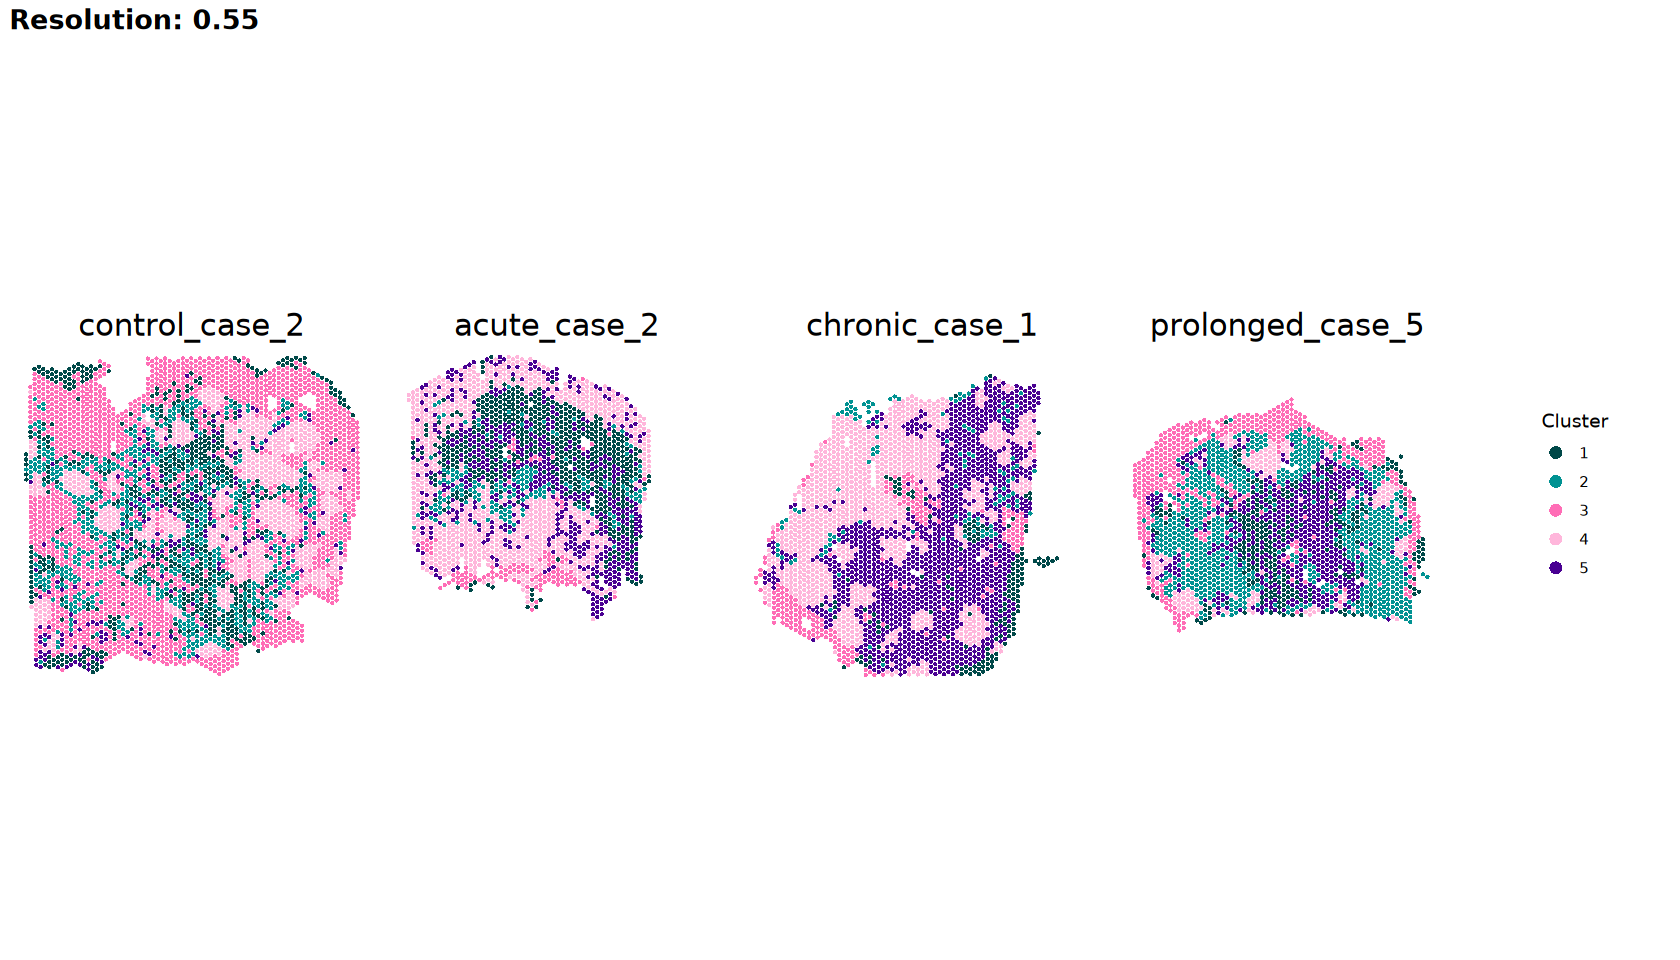

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale f

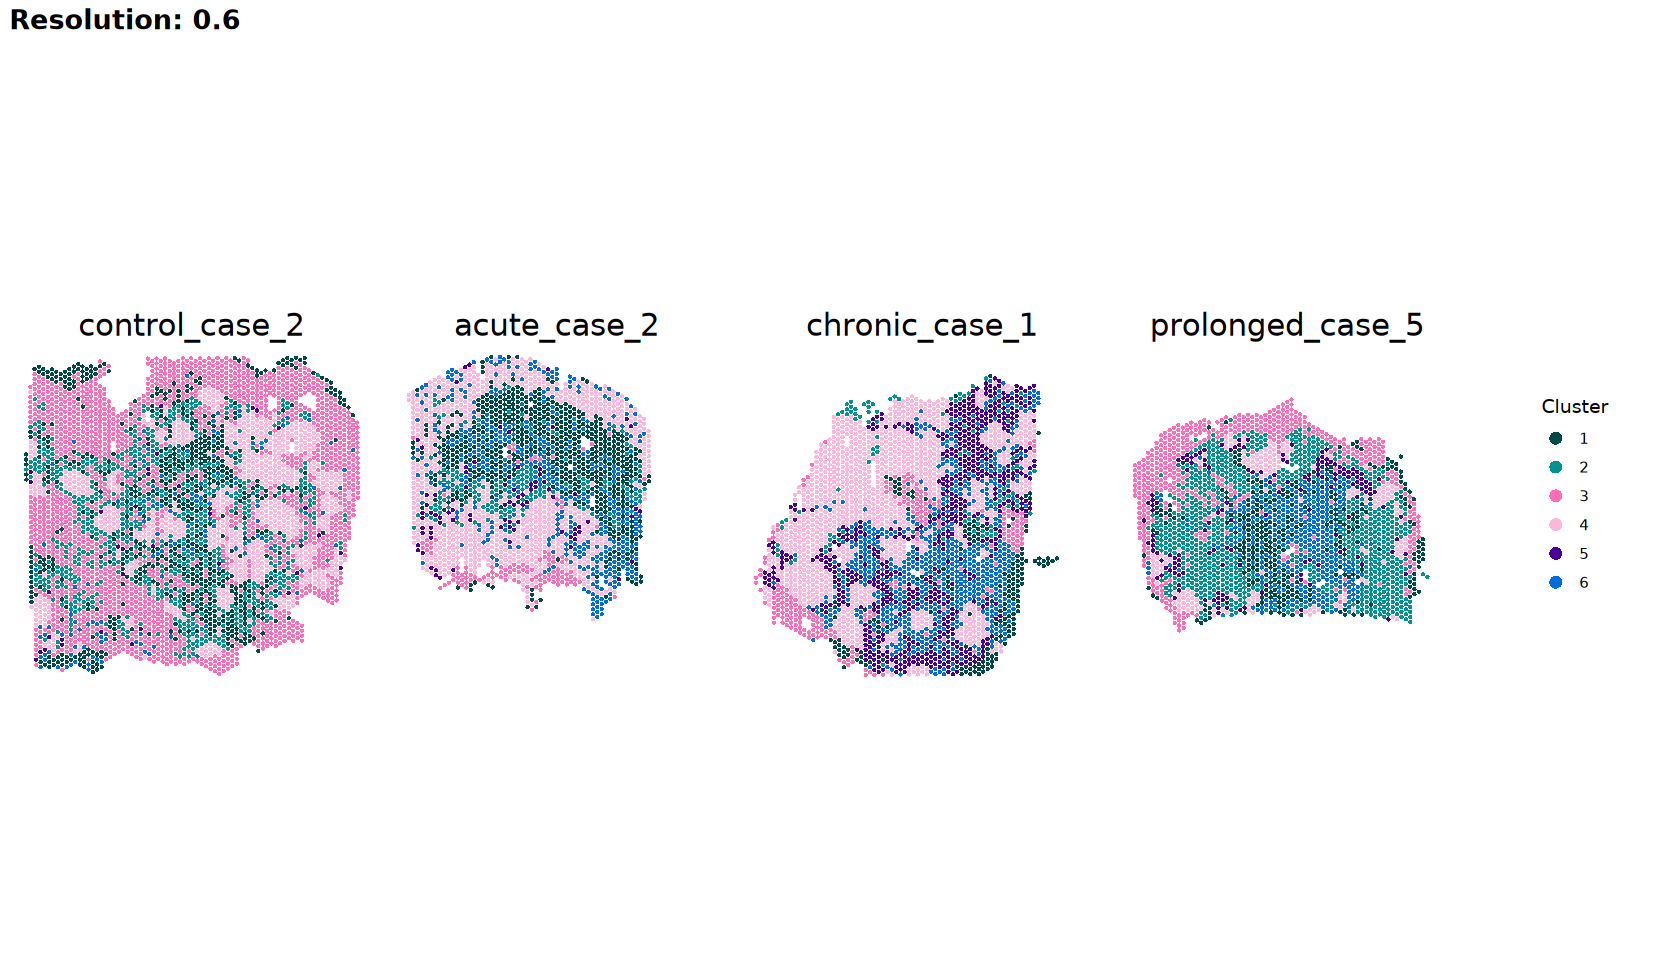

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale f

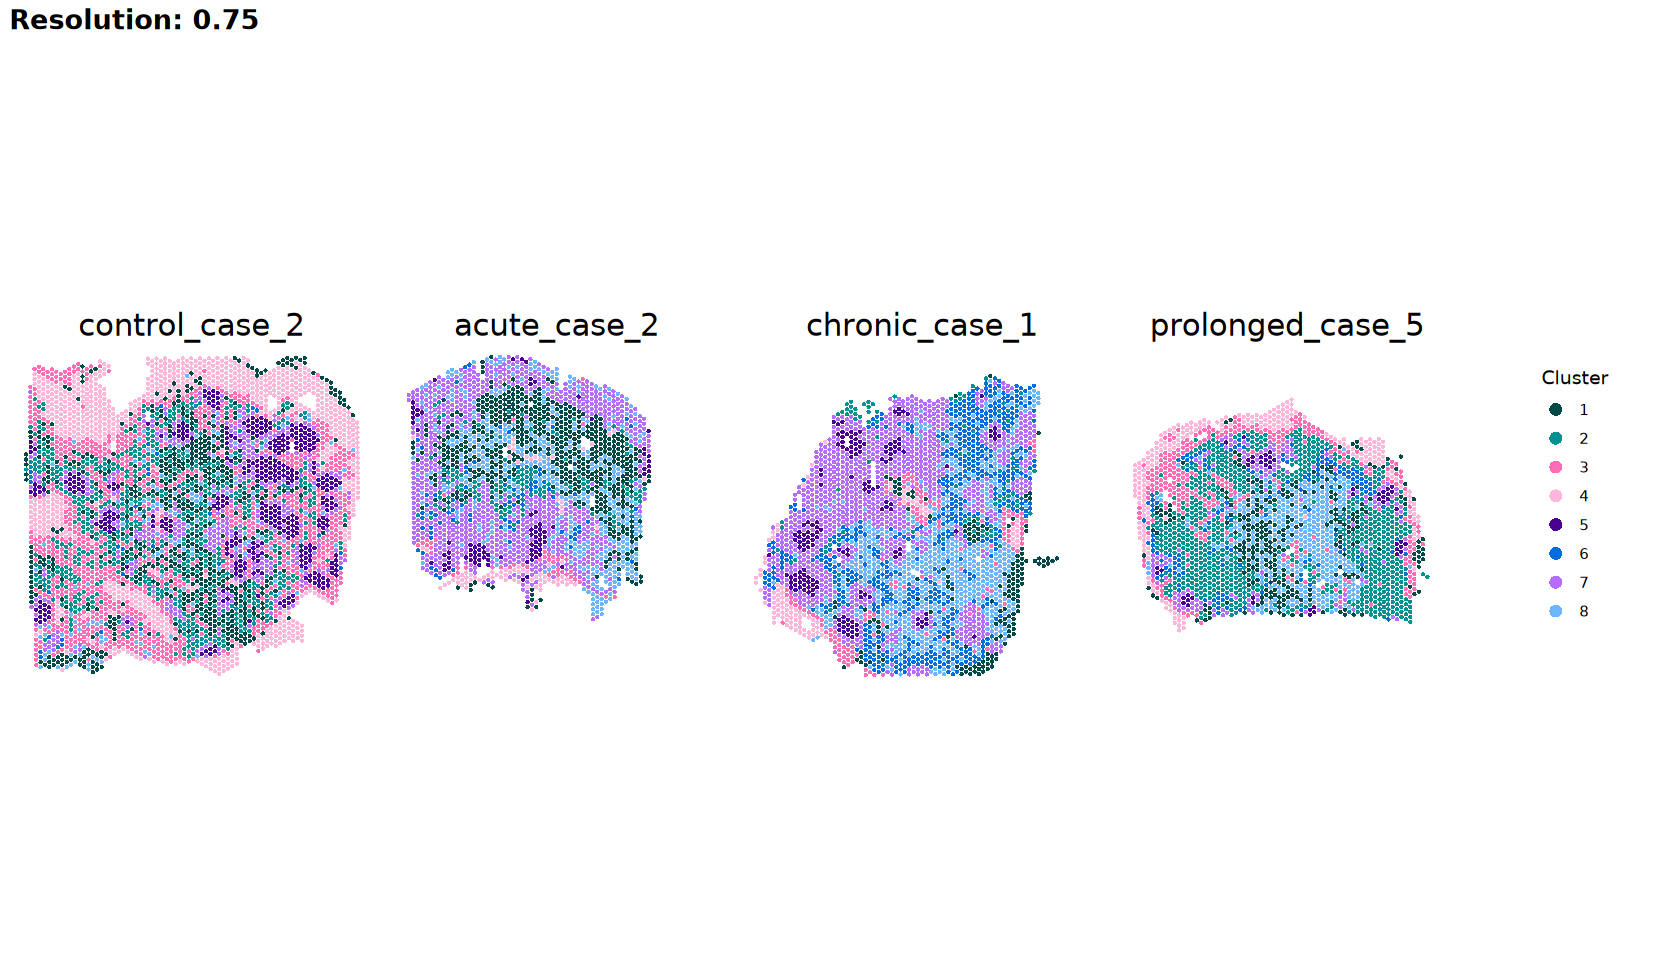

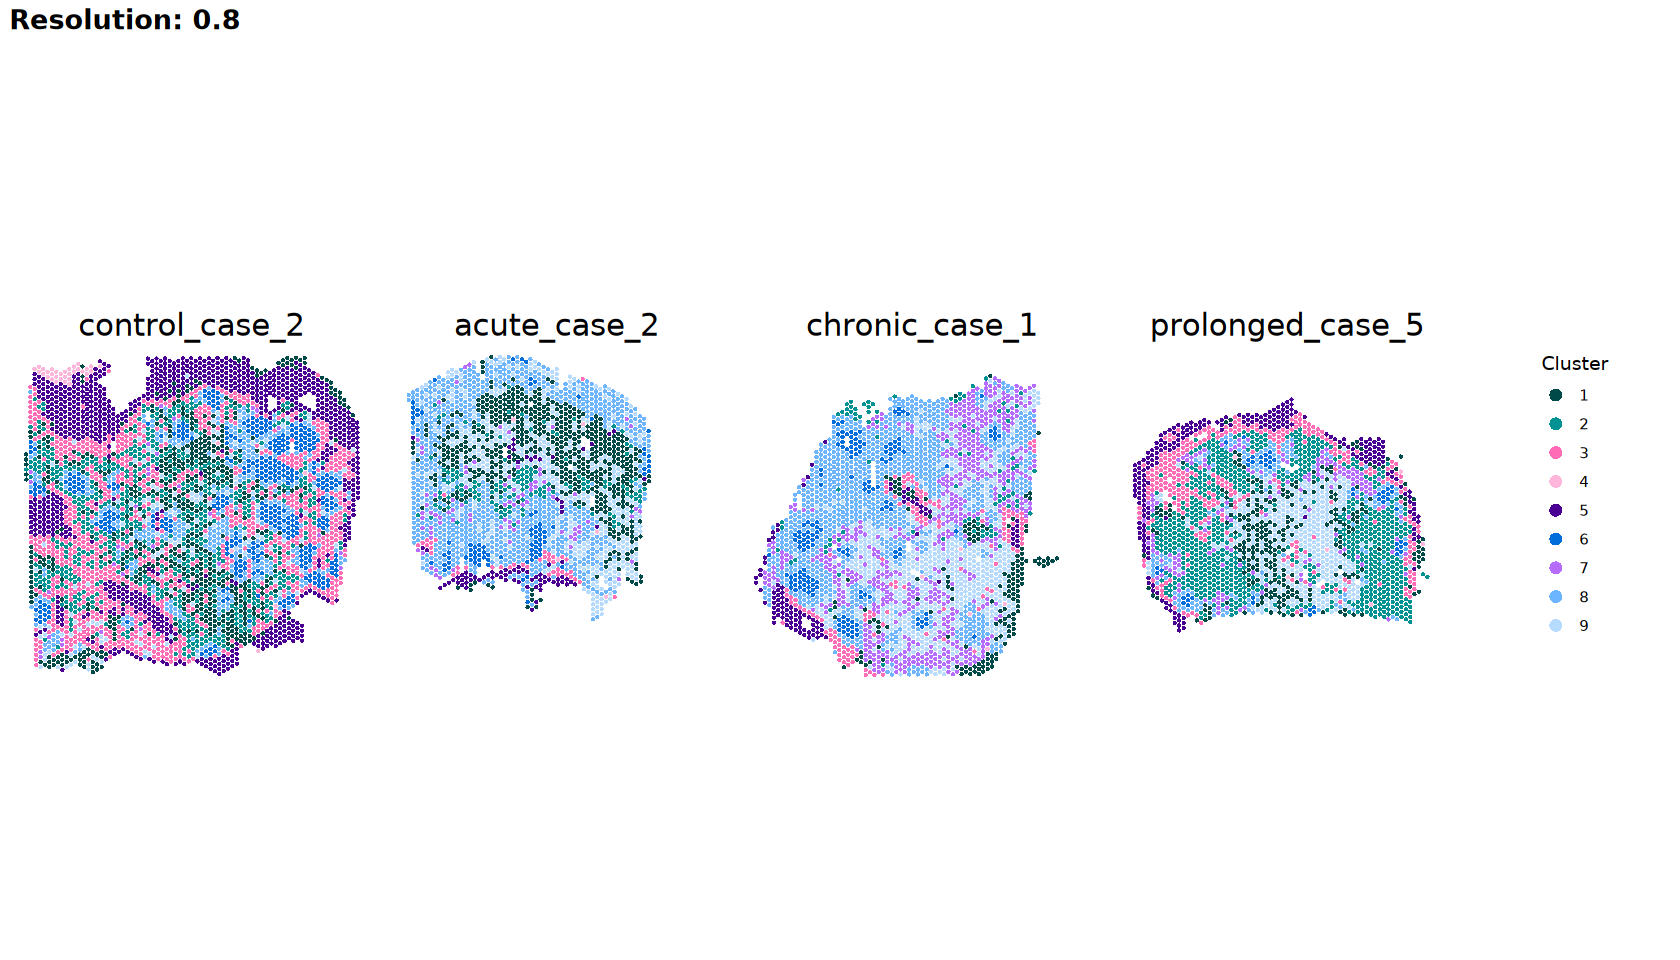

In [5]:
options(repr.plot.width = 14, repr.plot.height = 8, warn = -1)

global_x_min <- min(spatialCoords(spe)[, 1])
global_x_max <- max(spatialCoords(spe)[, 1])
global_y_min <- min(spatialCoords(spe)[, 2])
global_y_max <- max(spatialCoords(spe)[, 2])

for (res in resolutions) {
    
    cluster_col <- paste0("Leiden_res_", res)
    clusters <- sort(unique(spe[[cluster_col]]))
    palette <- paletteMartin[2:(length(clusters)+1)]
    names(palette) <- clusters

    legend <- plotCoords(spe, annotate = cluster_col, point_size = 0.6) +
    scale_color_manual(values = palette, drop = FALSE, name = "Cluster") +
    theme(legend.position = "right")
    
    legend <- cowplot::get_legend(legend)

    p <- list()
    for (id in unique(spe$study_id)) {

        sub <- spe[, spe$study_id == id]
        
        plot_i <- plotCoords(sub, annotate = cluster_col, point_size = 0.6) +
        scale_color_manual(values = palette, drop = FALSE) + 
        coord_fixed() + 
        ggplot2::xlim(global_x_min, global_x_max) + 
        ggplot2::ylim(global_y_max, global_y_min) + 
        ggtitle(paste0(id)) +
        theme_void() +
        theme(legend.position = "none",
             plot.title = element_text(hjust = 0.5, size = 18)) 
    
        p[[id]] <- plot_i
    }

    comb <- wrap_plots(p, ncol = 4) 
    comb <- wrap_plots(comb, legend, ncol = 2, widths = c(8, 1)) +
    plot_annotation(title = paste("Resolution:", res),
                    theme = theme(plot.title = element_text(size = 16, face = "bold")))
    print(comb)
}

In [6]:
spe$annotation <- spe$Leiden_res_0.75

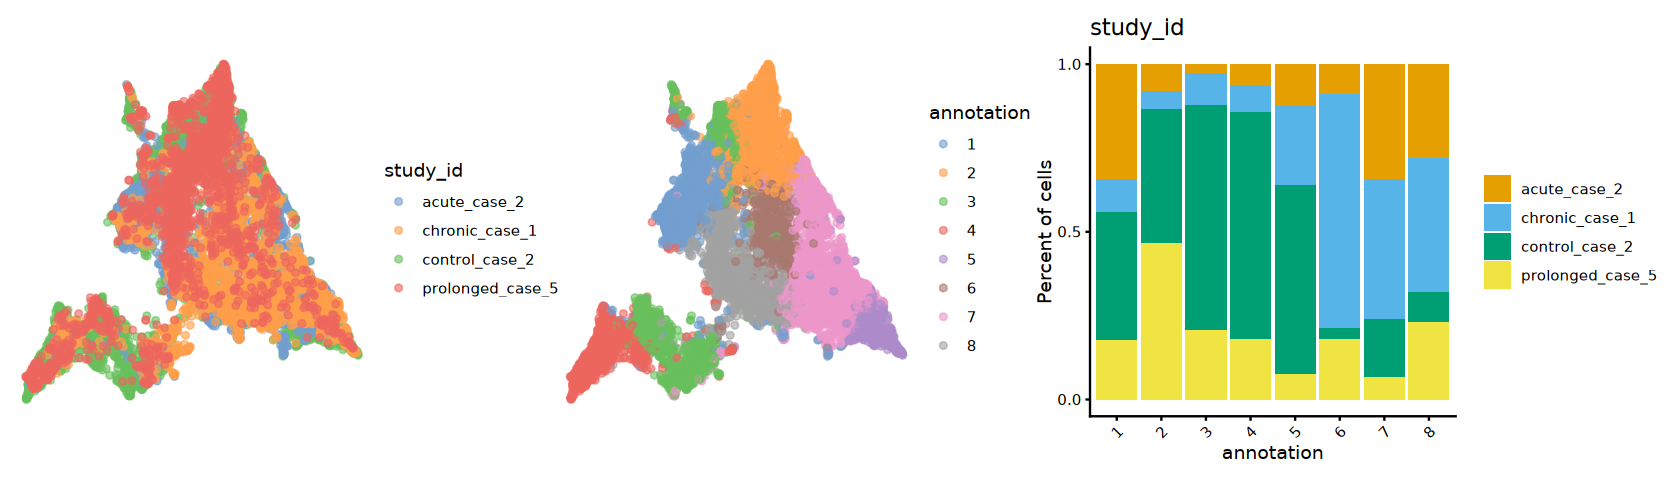

In [7]:
options(repr.plot.width = 14, repr.plot.height = 4, warn = -1)

p1 <- plotReducedDim(spe, dimred = "UMAP", colour_by = "study_id") +
  theme_void()
p2 <- plotReducedDim(spe, dimred = "UMAP", colour_by = "annotation") +
  theme_void()
p3 <- dittoBarPlot(spe, "study_id", group.by = "annotation")

p1 | p2 | p3

In [8]:
pca_coords <- reducedDim(spe, "HARMONY")
metadata <- colData(spe) %>% 
  as.data.frame() %>%
  select(study_id)
lisi_scores <- compute_lisi(pca_coords, metadata, c("study_id"))
spe$lisi_study_id <- lisi_scores$study_id

cat("LISI Score Summary:\n")
cat("Mean LISI:", mean(lisi_scores$study_id), "\n")
cat("Median LISI:", median(lisi_scores$study_id), "\n")
cat("Range:", range(lisi_scores$study_id), "\n\n")

LISI Score Summary:
Mean LISI: 1.83587 
Median LISI: 1.736068 
Range: 1 3.987543 



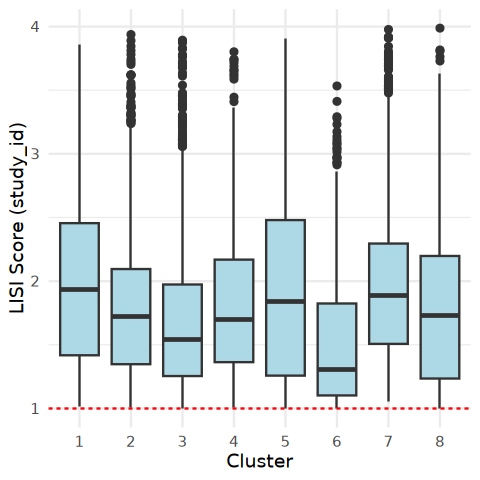

In [9]:
options(repr.plot.width = 4, repr.plot.height = 4, warn = -1)

ggplot(as.data.frame(colData(spe)), 
       aes(x = annotation, y = lisi_study_id)) +
  geom_boxplot(fill = "lightblue") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  labs(x = "Cluster",
       y = "LISI Score (study_id)") +  
  theme_minimal()

## Differtential expression

In [10]:
genes <- rowData(spe)$symbol
mt <- grepl("^MT-|^MTRNR", genes, ignore.case = TRUE)
spe <- spe[!mt, ]

mgs <- findMarkers(spe, groups = spe$annotation, direction = "up")

In [11]:
top <- lapply(mgs, \(df) rownames(df)[df$Top <= 2])
length(top <- unique(unlist(top)))

[1] 51

In [12]:
mat <- logcounts(spe)[top, ]
groups <- spe$annotation
split_mat <- split(seq_len(ncol(mat)), groups)

aggregate_means <- lapply(split_mat, function(i) {
    Matrix::rowMeans(mat[, i, drop = FALSE])
})

pbs <- do.call(cbind, aggregate_means)
colnames(pbs) <- names(aggregate_means)

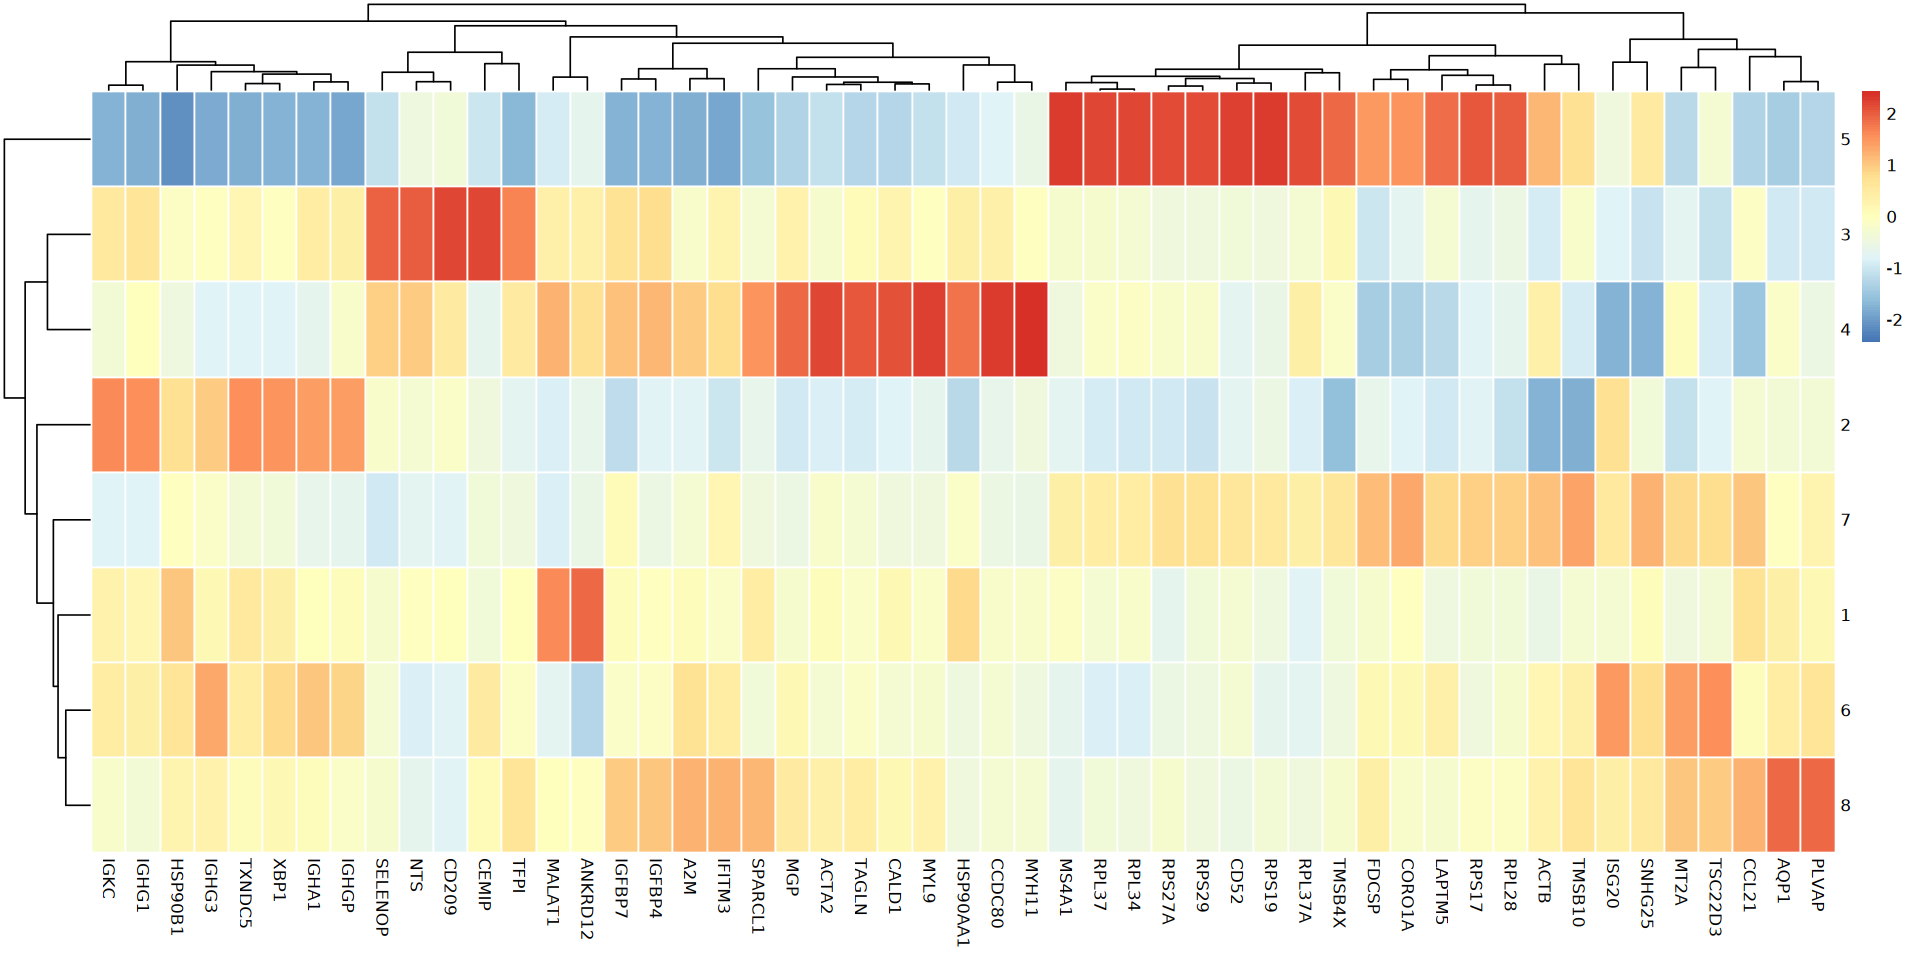

In [13]:
options(repr.plot.width = 16, repr.plot.height = 8, warn = -1)

mtx <- t(pbs)
colnames(mtx) <- rowData(spe)[top, ]$gene_name
pheatmap(mat = mtx, scale = "column", border_color = "white")

## Cluster 1

In [14]:
plot_cluster <- function(cluster = "", n = 4) {
lapply(unique(spe$study_id), function(id) {
    sub <- spe[, spe$study_id == id]
    
    if (cluster %in% sub$annotation) {
        sub$highlight <- ifelse(sub$annotation == cluster, paste0("Cluster ", cluster), "Other")

        
        plotCoords(sub, annotate = "highlight", point_size = 0.6) +
            scale_color_manual(values = c(setNames("red", paste0("Cluster ", cluster)), "Other" = "gray80")) +
            coord_fixed() + 
            ggplot2::xlim(global_x_min, global_x_max) + 
            ggplot2::ylim(global_y_max, global_y_min) + 
            ggtitle(paste0(id)) +
            theme_void() +
            theme(plot.title = element_text(hjust = 0.5, size = 18)) 
    } else {
        NULL  
    }
}) %>% 
    compact() %>% 
    wrap_plots(ncol = n, guides = "collect")
}

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

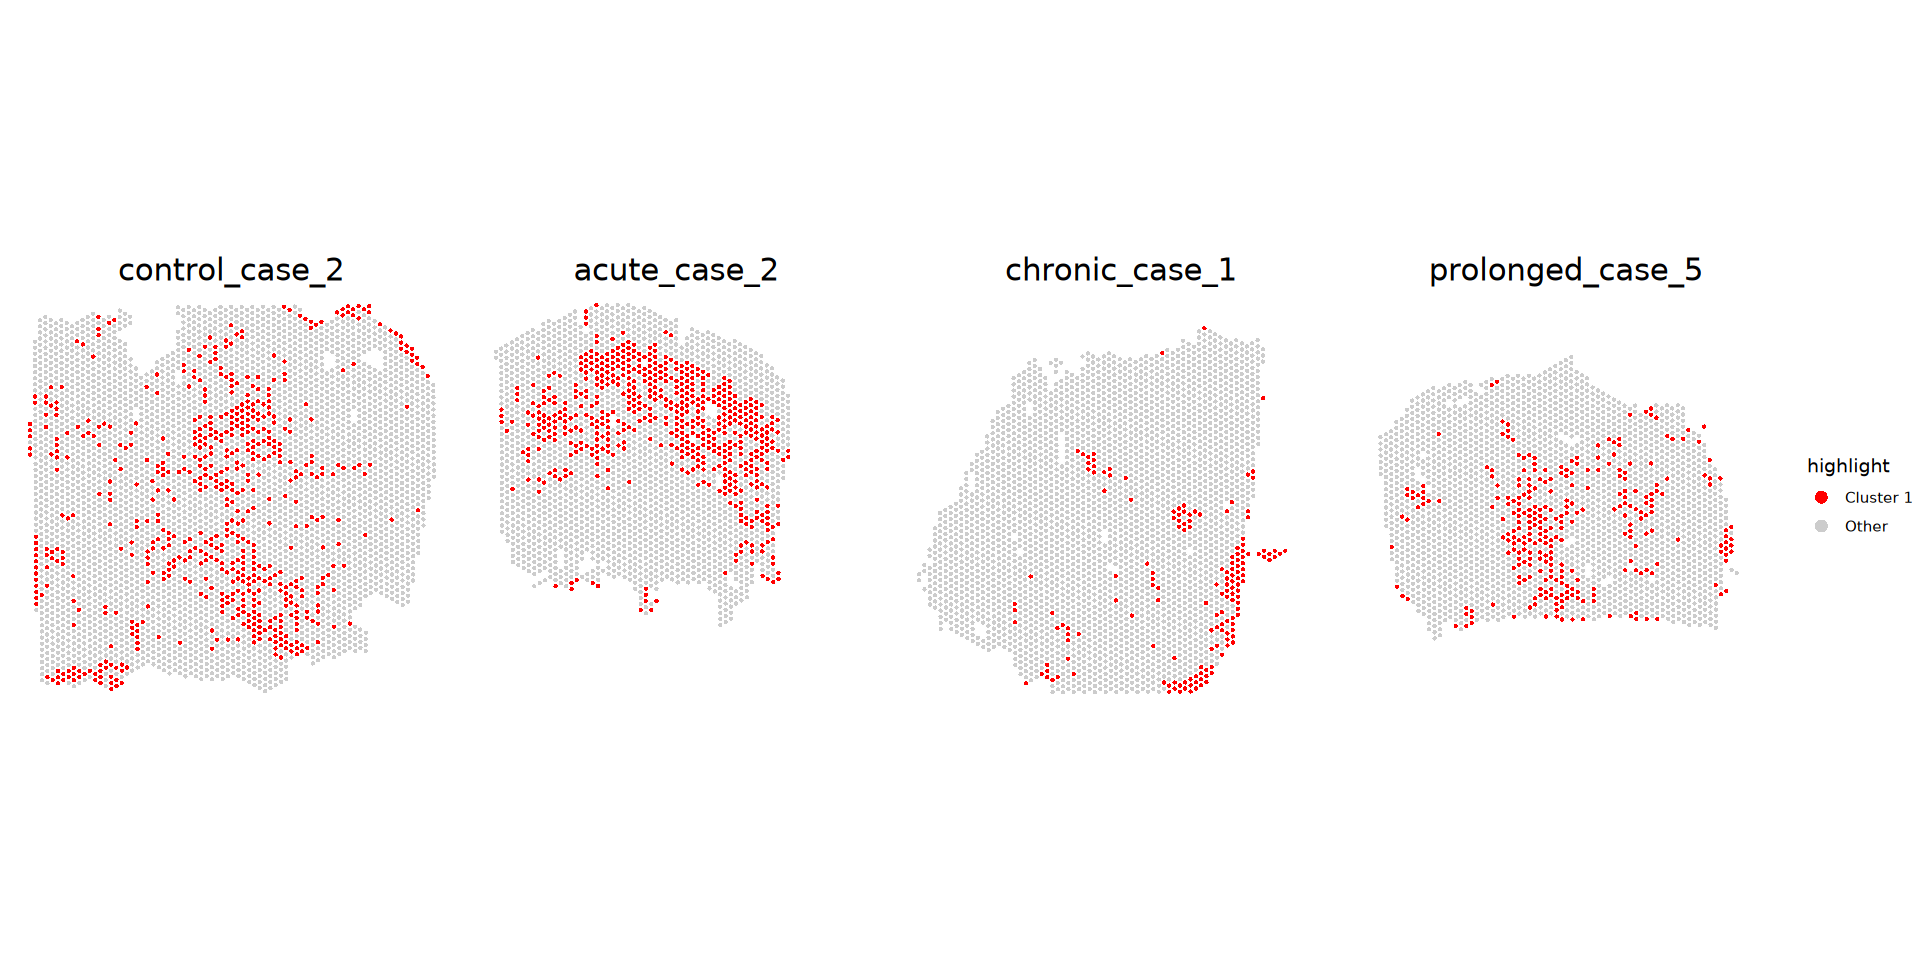

In [15]:
plot_cluster(1)

In [16]:
rowData(spe)[rownames(subset(mgs$'1', Top <= 10)), ]$gene_name

[1] "IGKC"       "CCL21"      "MALAT1"     "HSP90B1"    "HSP90AA1"  
 [6] "IGHG1"      "ANKRD12"    "TXNDC5"     "AQP1"       "AKAP9"     
[11] "IGLC1"      "CCDC88A"    "ANKRD36C"   "IGFBP7"     "IGHG3"     
[16] "IGLC2"      "GOLGA4"     "PABPC1"     "MPHOSPH8"   "XBP1"      
[21] "TENT5C"     "PTMA"       "ATRX"       "JCHAIN"     "AC007952.4"
[26] "IGLC3"      "BOD1L1"     "SPARCL1"    "SNHG25"     "FKBP11"    
[31] "ARGLU1"     "RBM25"      "FDCSP"      "PNISR"

## Cluster 2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

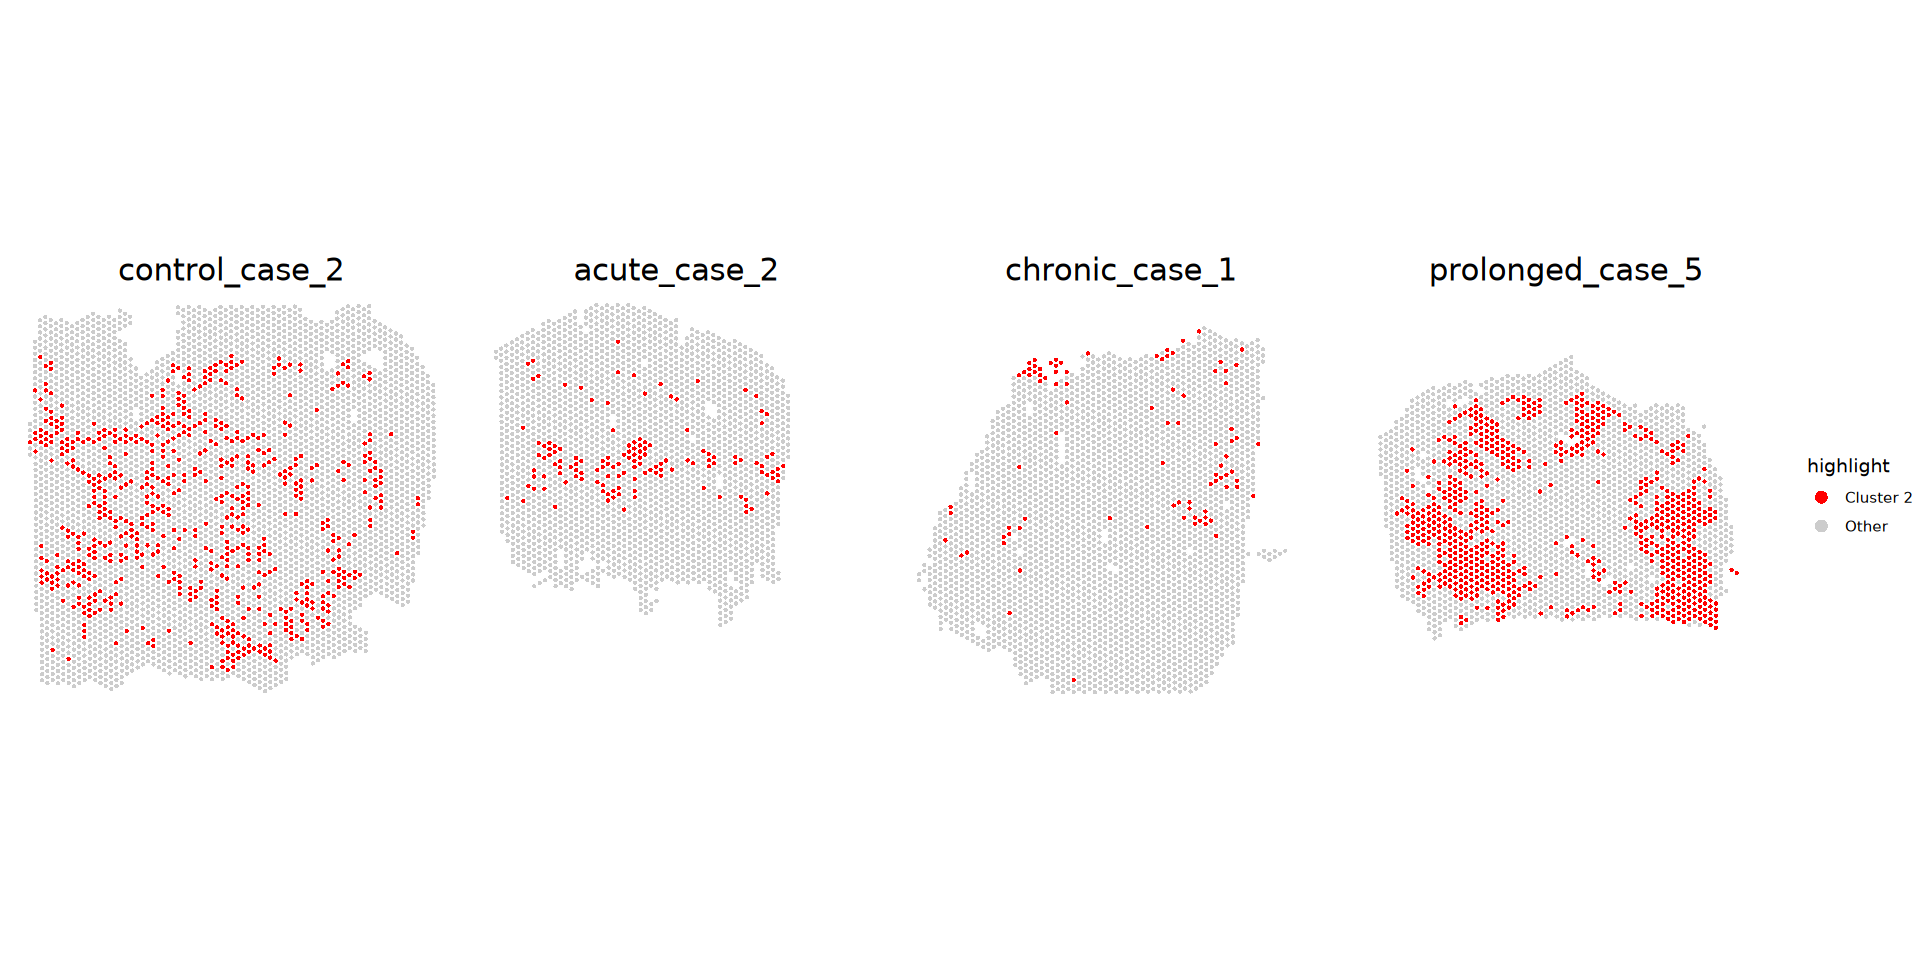

In [17]:
plot_cluster(2)

In [18]:
rowData(spe)[rownames(subset(mgs$'2', Top <= 3)), ]$gene_name

[1] "IGKC"   "TXNDC5" "IGHG1"  "XBP1"   "MZB1"   "IGHGP"  "IGHA1"  "IGLC1" 
[9] "SSR4"

## Cluster 3

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

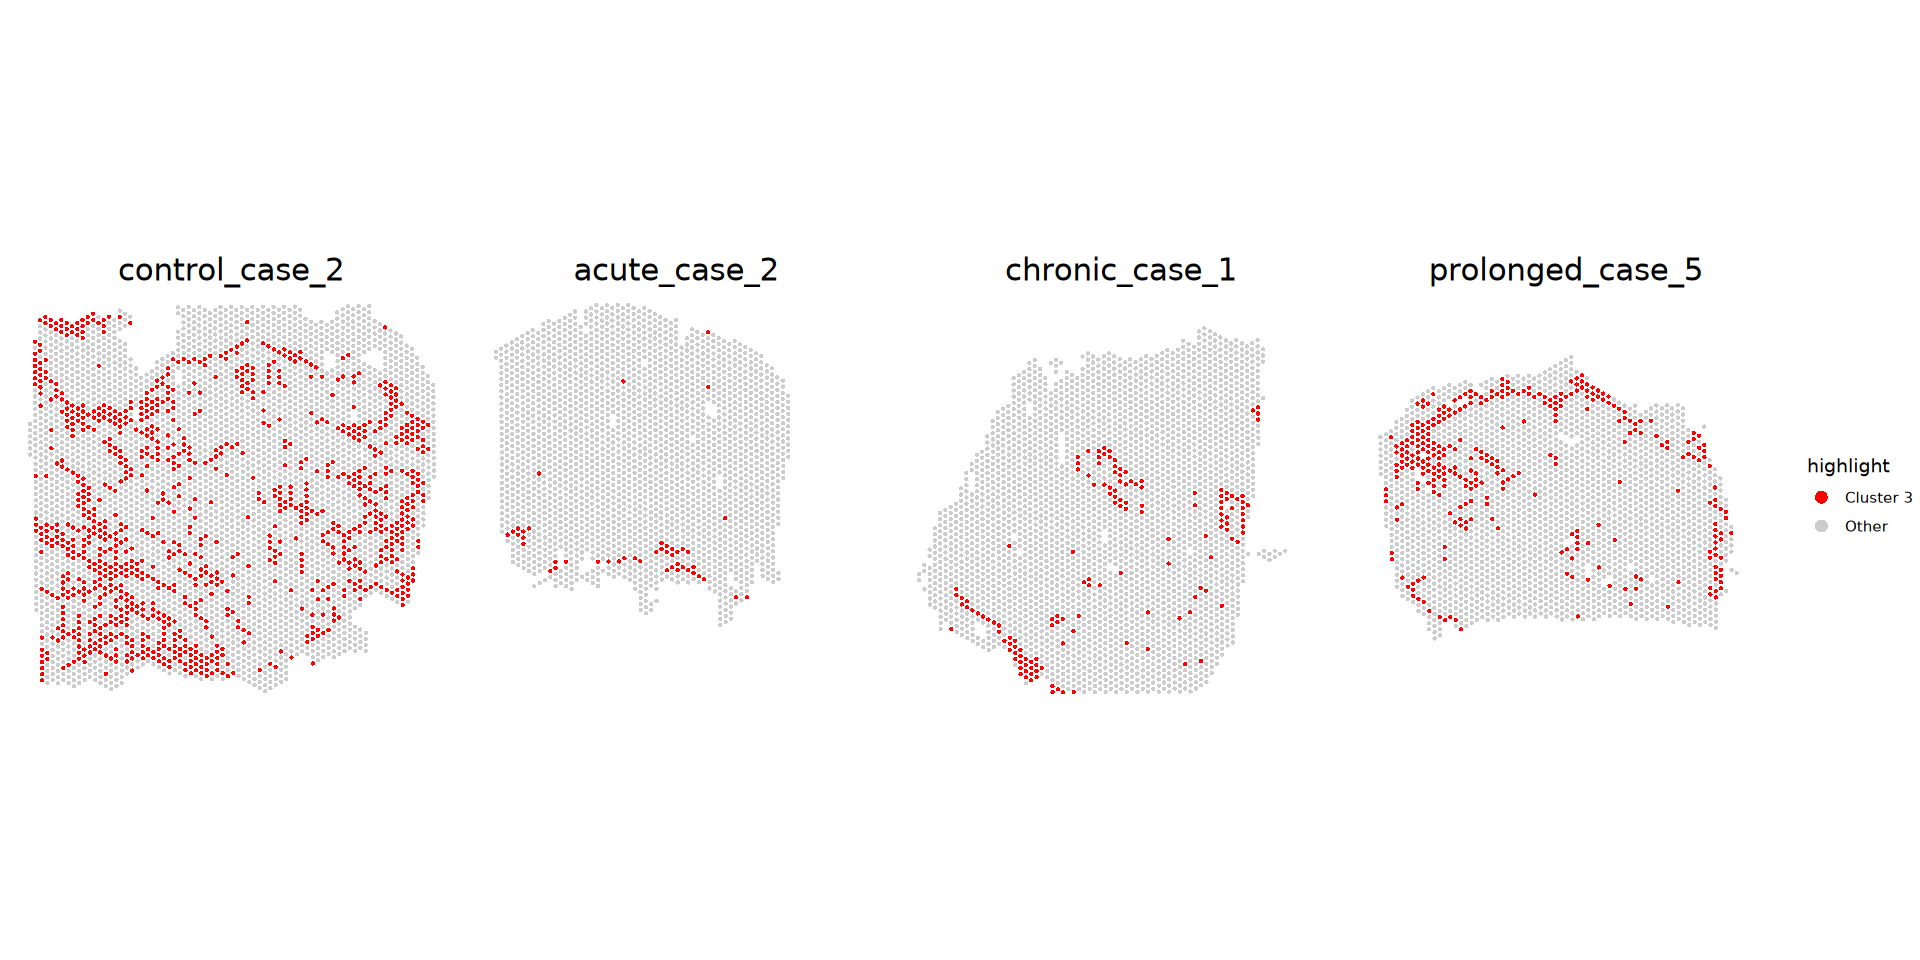

In [19]:
plot_cluster(3)

In [20]:
rowData(spe)[rownames(subset(mgs$'3', Top <= 3)), ]$gene_name

[1] "IGKC"    "IGFBP7"  "SELENOP" "NTS"     "CEMIP"   "TFPI"    "IGHA1"  
 [8] "IGHG1"   "CD209"   "MARCO"   "LYVE1"   "CLDN5"   "IGLC1"

## Cluster 4

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

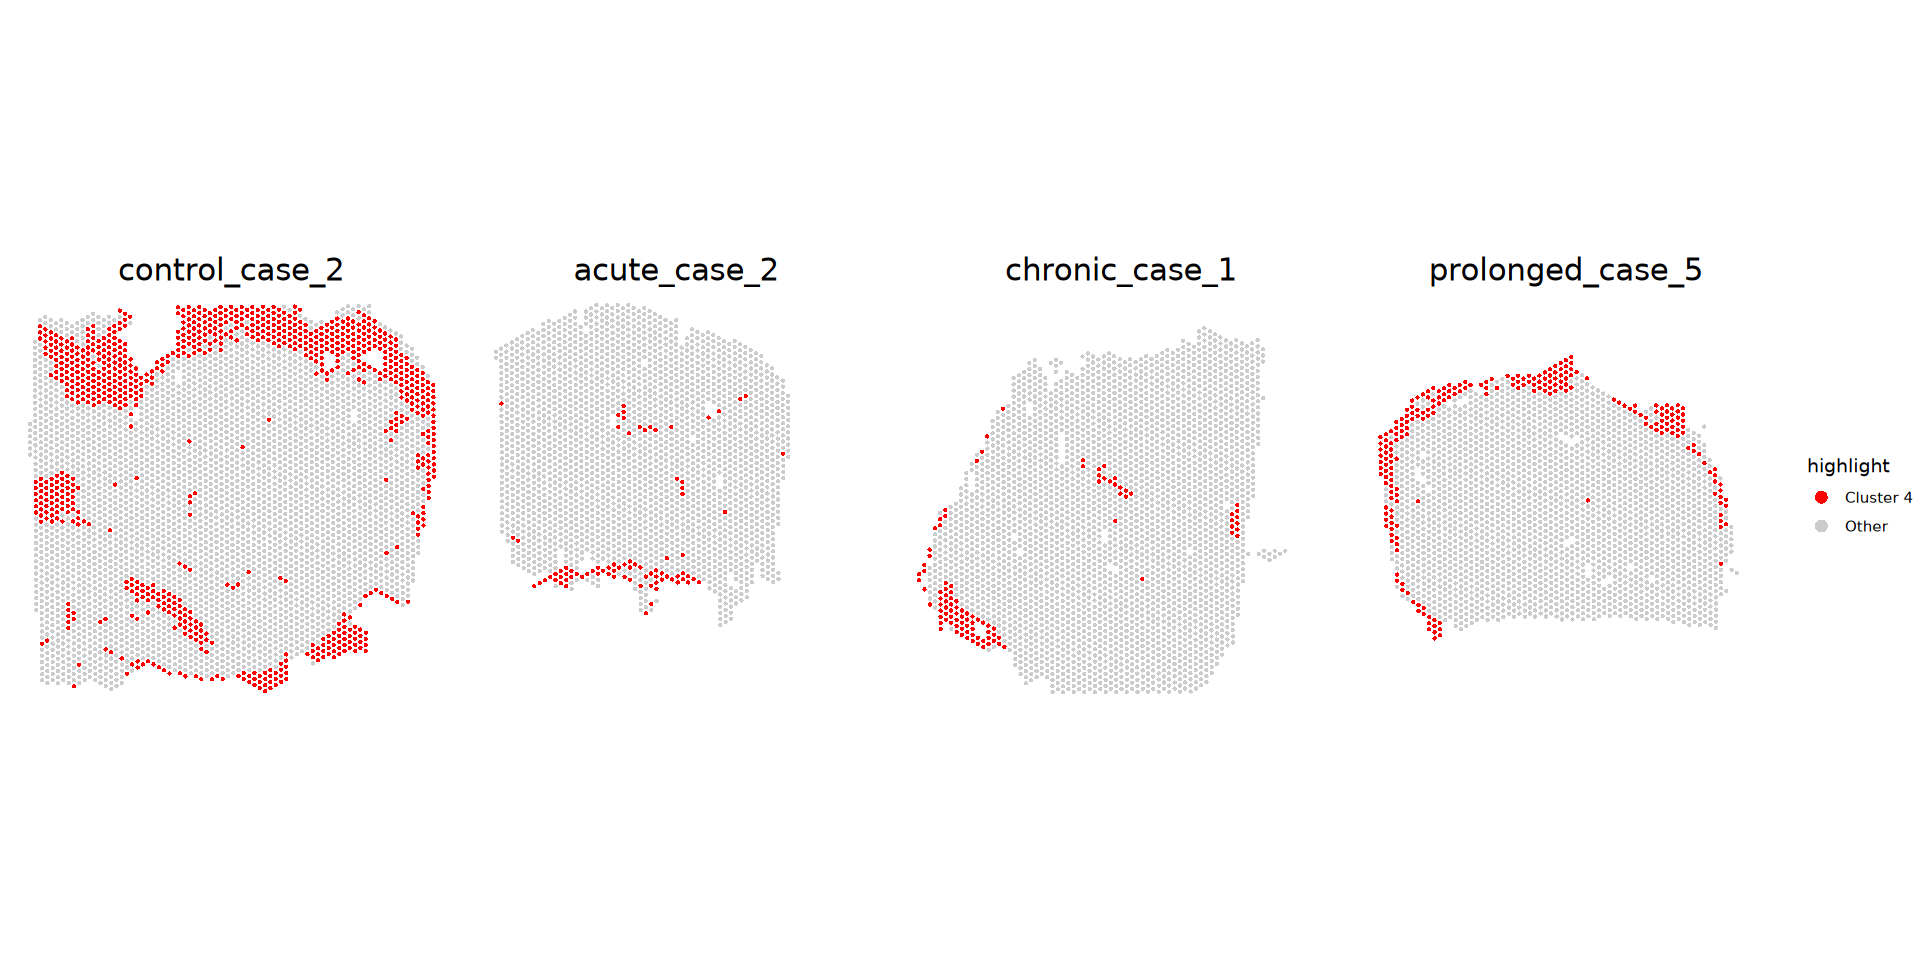

In [21]:
plot_cluster(4)

In [22]:
rowData(spe)[rownames(subset(mgs$'4', Top <= 10)), ]$gene_name

[1] "CCDC80"  "CALD1"   "ACTA2"   "MGP"     "TAGLN"   "MYH11"   "MYL9"   
 [8] "DES"     "MYLK"    "IGFBP7"  "CFD"     "IGFBP5"  "SPARCL1" "FBLN1"  
[15] "APOD"    "MAP1B"   "CST3"    "MALAT1"  "TPM1"    "S100A6"  "RPLP1"  
[22] "SYNPO2"  "TPM2"

## Cluster 5

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

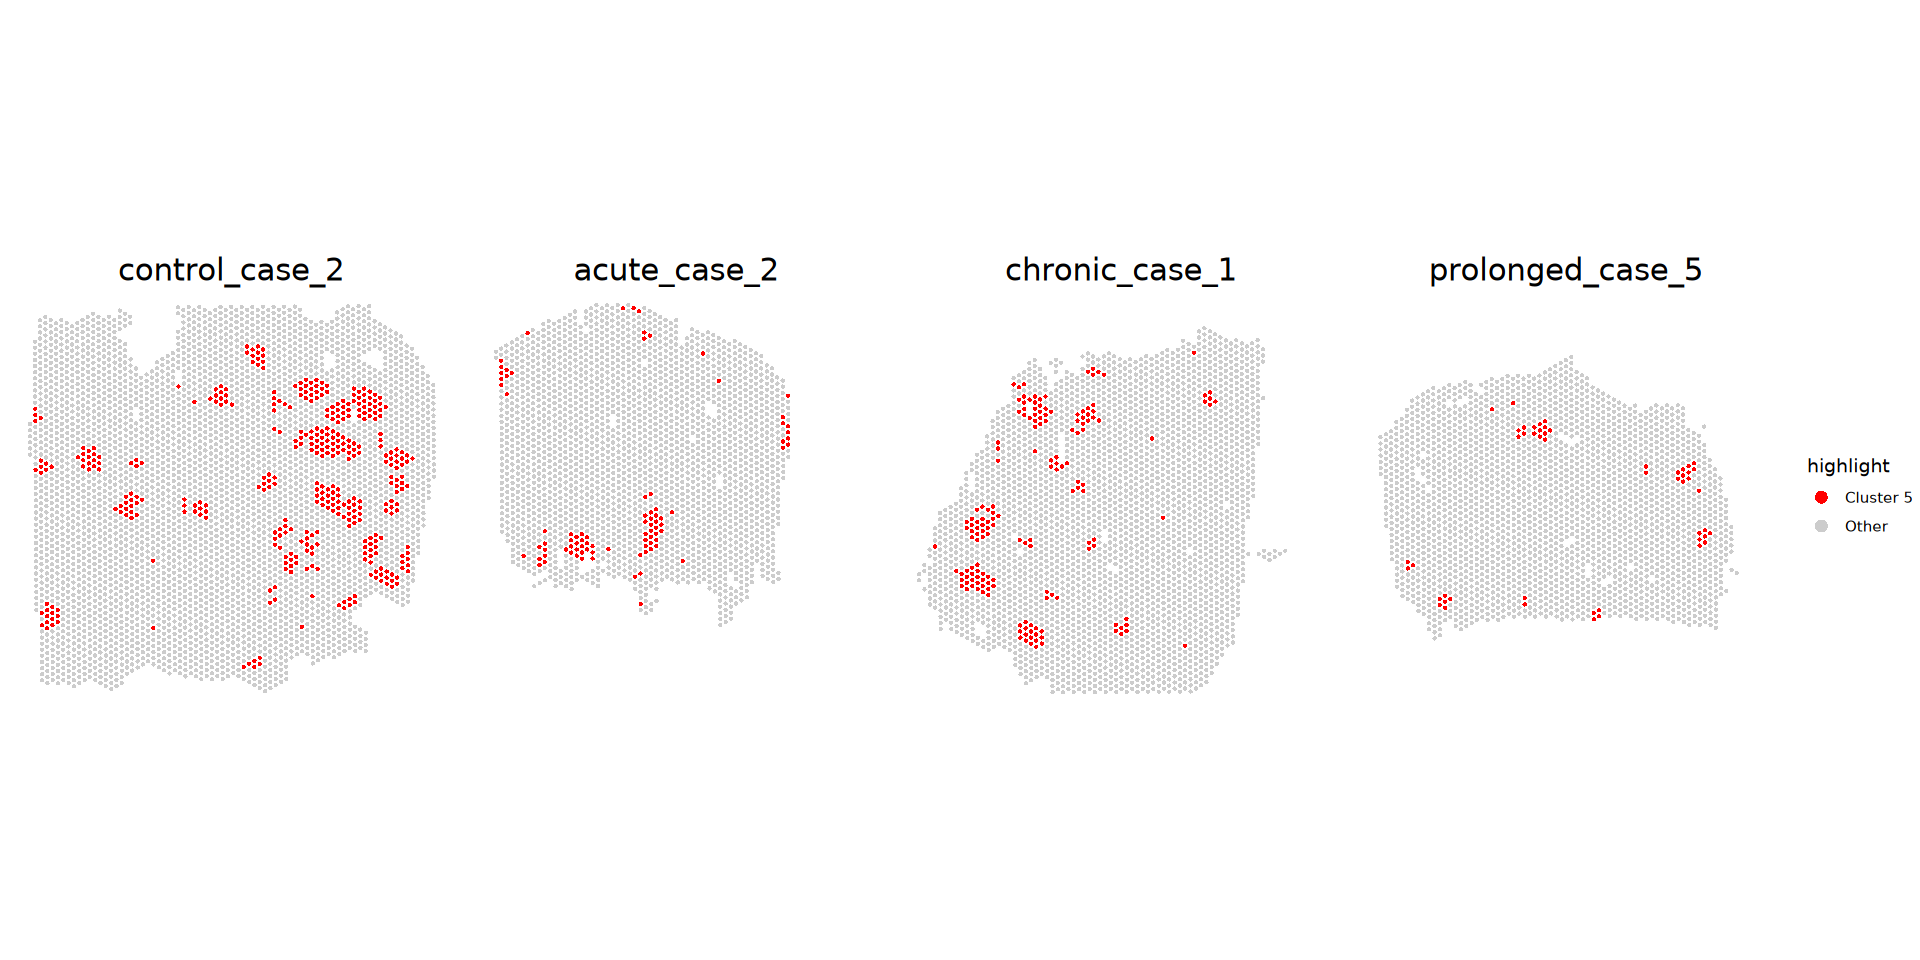

In [23]:
plot_cluster(5)

In [24]:
rowData(spe)[rownames(subset(mgs$'5', Top <= 3)), ]$gene_name

[1] "CD52"   "RPL37A" "MS4A1"  "TMSB4X" "LAPTM5" "RPS27A" "RPS17"  "RPS19" 
 [9] "RPS29"  "CD19"   "RPL26"  "RPL28"

## Cluster 6

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

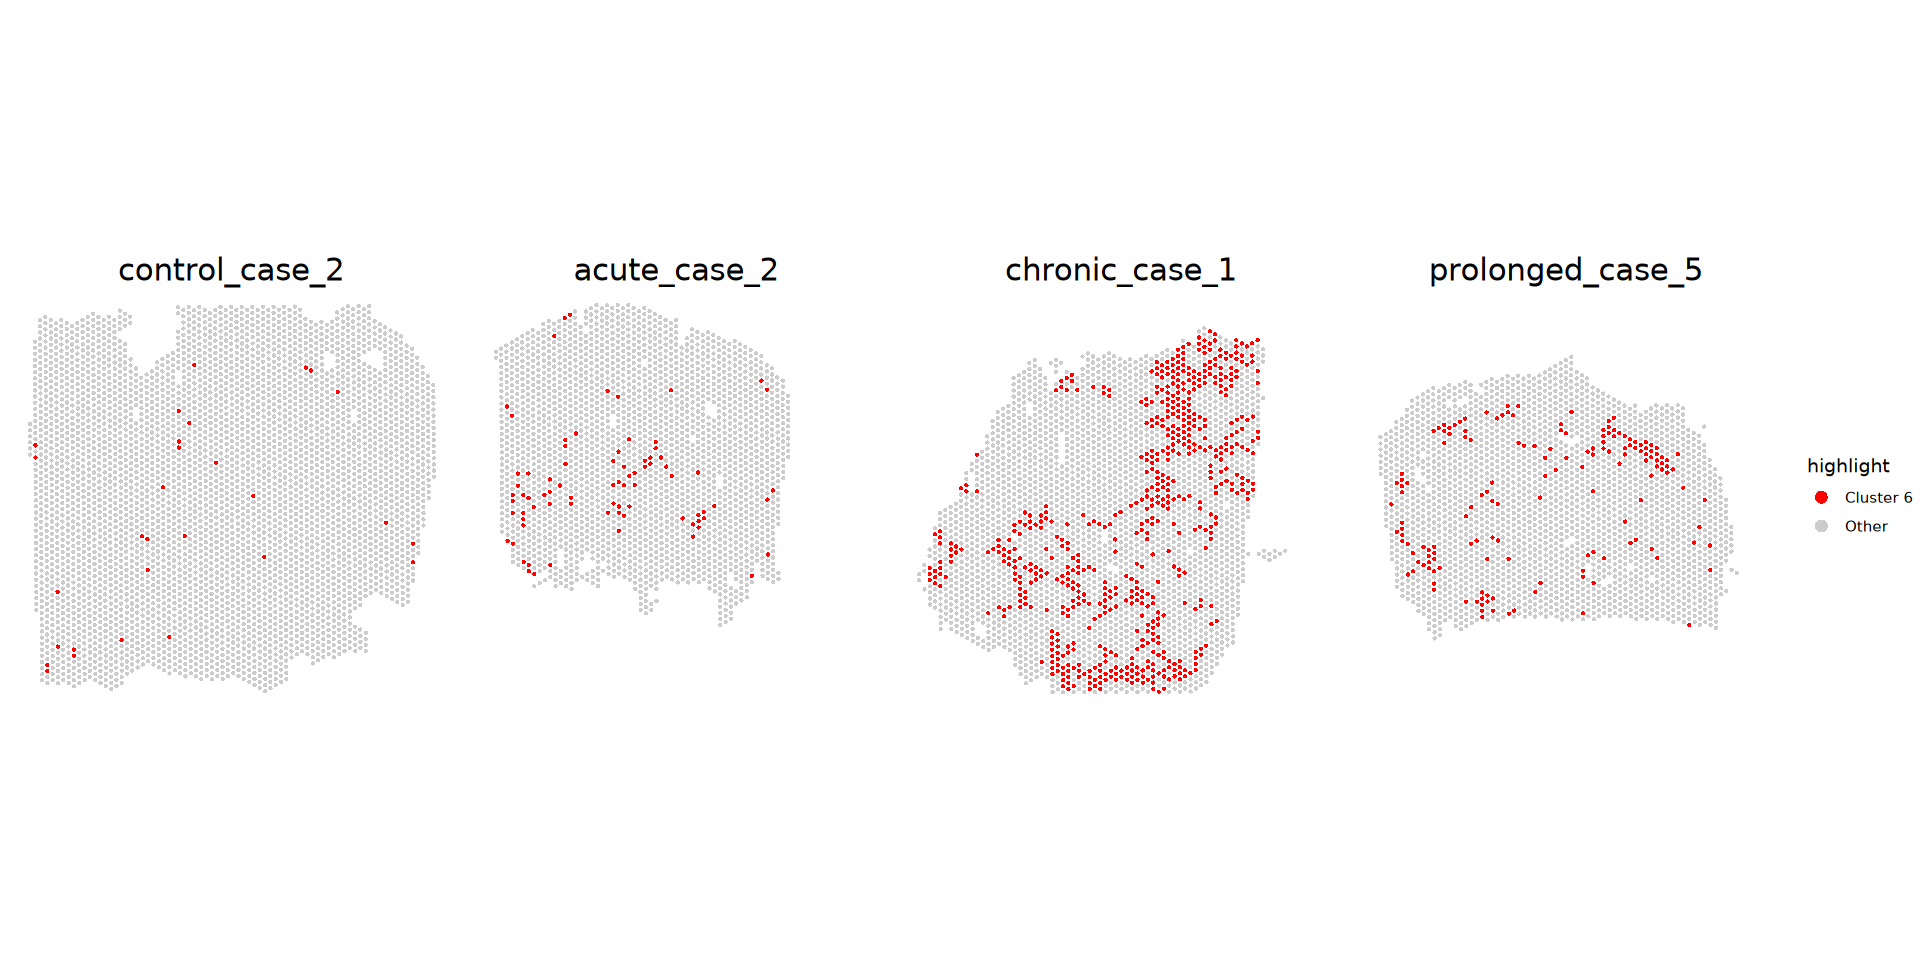

In [25]:
plot_cluster(6)

In [26]:
rowData(spe)[rownames(subset(mgs$'6', Top <= 3)), ]$gene_name

[1] "IGKC"    "IGHG3"   "MT2A"    "ACTB"    "IGHGP"   "IGHA1"   "ISG20"  
 [8] "TSC22D3" "CXCL9"   "MZB1"    "TIMP1"

## Cluster 7

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

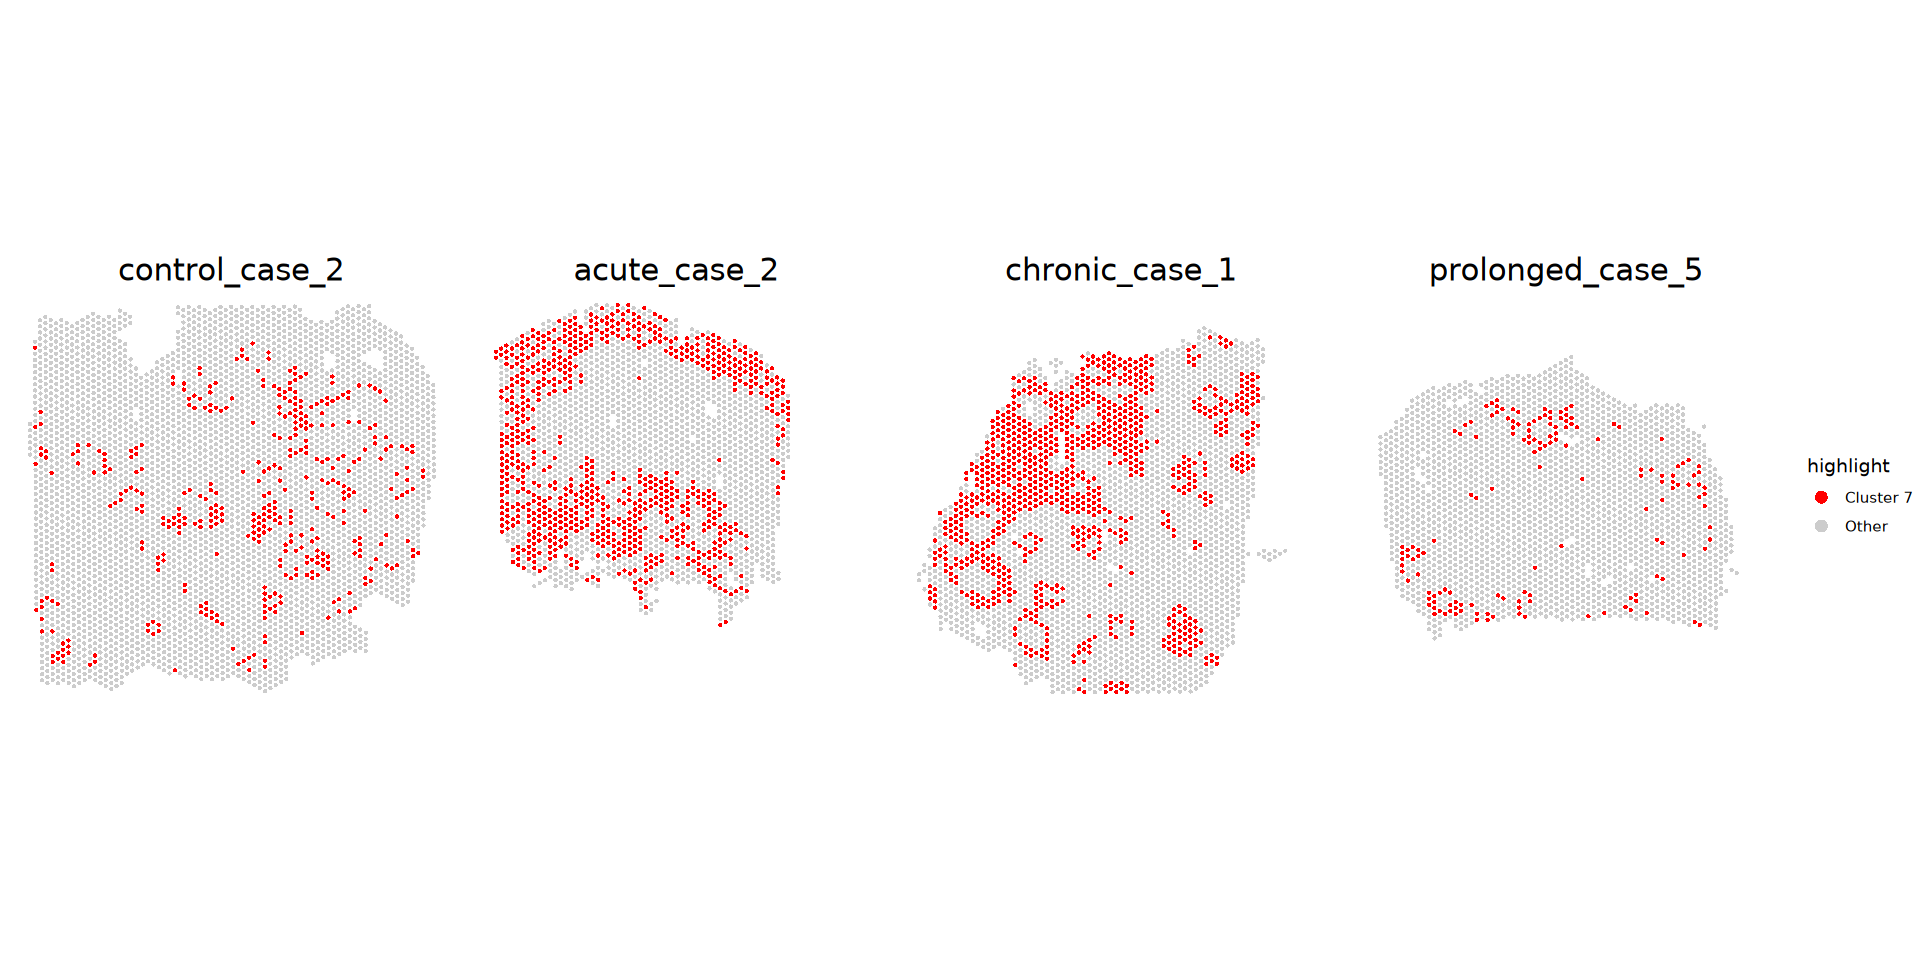

In [27]:
plot_cluster(7)

In [28]:
rowData(spe)[rownames(subset(mgs$'7', Top <= 3)), ]$gene_name

[1] "FDCSP"  "RPL37"  "ACTB"   "RPS29"  "IGHG3"  "CORO1A" "TMSB10" "IGKC"  
 [9] "RPL34"  "SNHG25" "RPL28"  "CD52"   "RPS27A" "RPL32"  "GAPDH"  "PFN1"  
[17] "IGLC3"

## Cluster 8

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

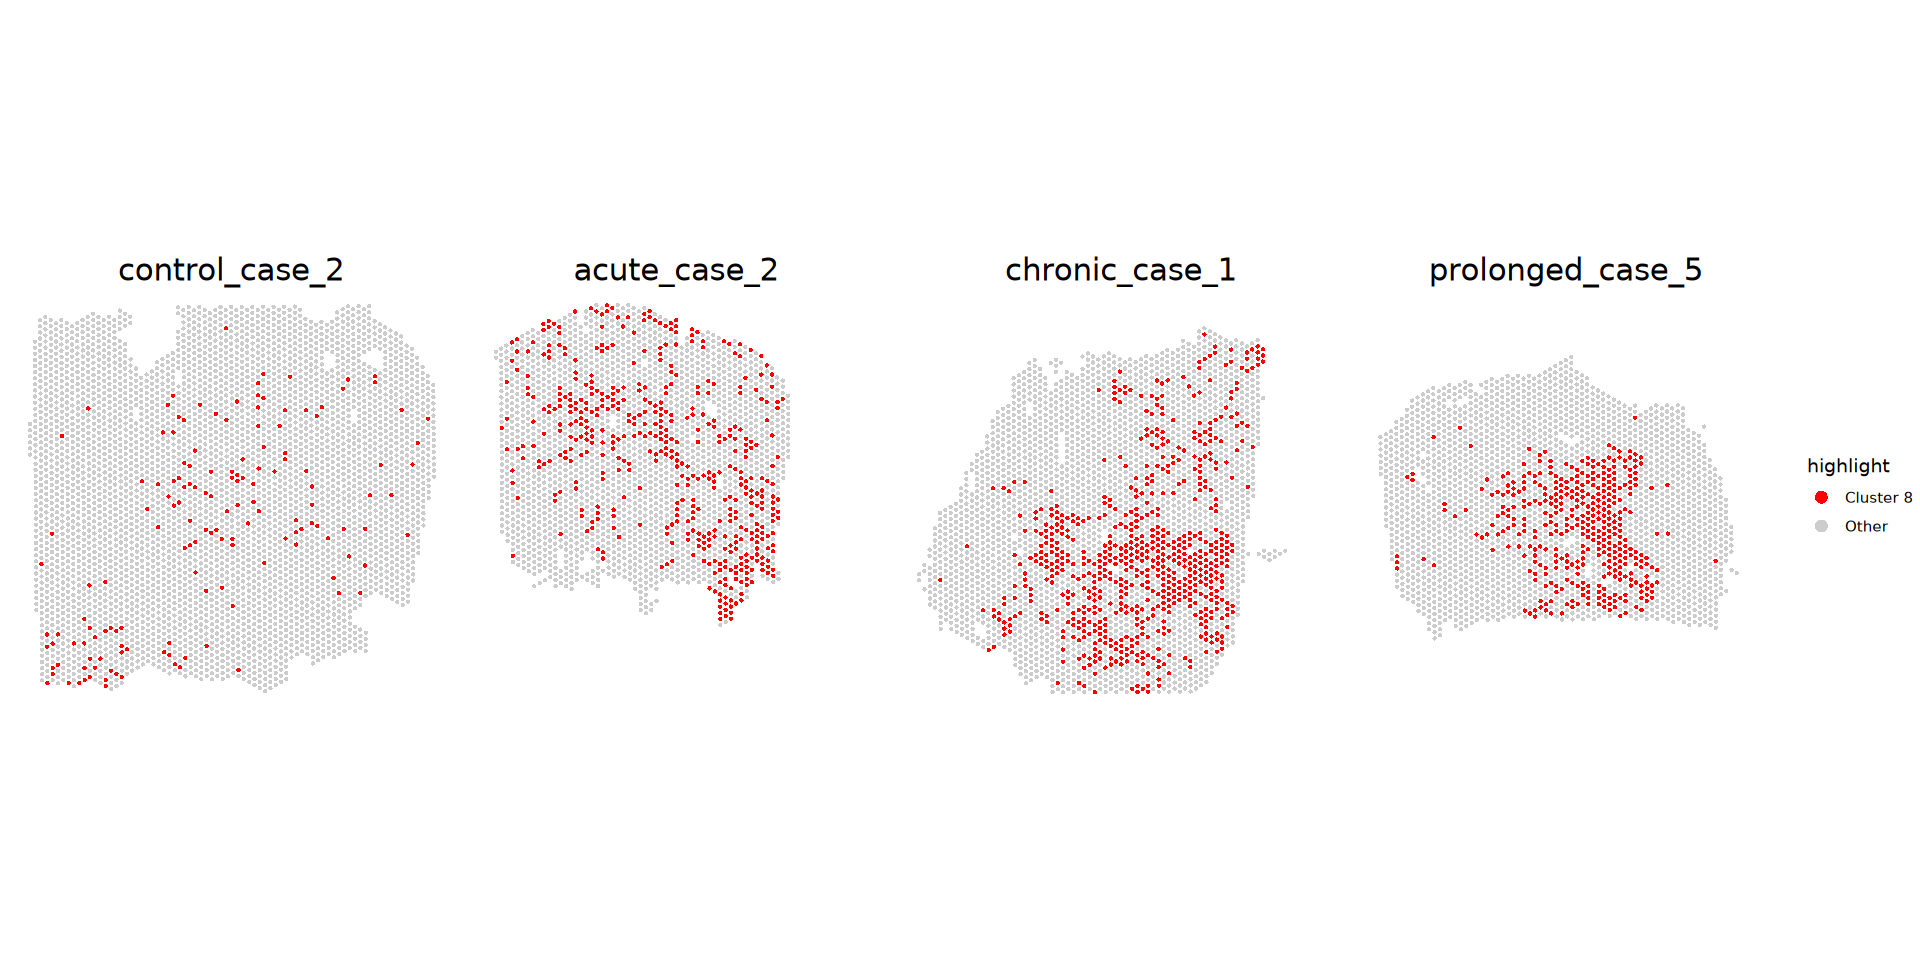

In [29]:
plot_cluster(8)

In [30]:
rowData(spe)[rownames(subset(mgs$'8', Top <= 3)), ]$gene_name

[1] "IGFBP7"  "SPARCL1" "AQP1"    "CCL21"   "A2M"     "IGKC"    "IFITM3" 
 [8] "IGFBP4"  "PLVAP"   "VWF"

## Annotation

In [31]:
spe$annotation <- case_when(spe$annotation == 1 ~ "Unassigned",
                            spe$annotation == 2 ~ "Plasma cells",
                            spe$annotation == 3 ~ "Macrophages", 
                            spe$annotation == 4 ~ "Smooth muscle/Myofibroblasts", 
                            spe$annotation == 5 ~ "Follicular", 
                            spe$annotation == 6 ~ "Plasma cells", 
                            spe$annotation == 7 ~ "Interfollicular", 
                            spe$annotation == 8 ~ "Vascular") 

In [32]:
mgs <- findMarkers(spe, groups = spe$annotation, direction = "up")
top <- lapply(mgs, \(df) rownames(df)[df$Top <= 3])

In [33]:
spe_dot <- spe
top <- rowData(spe_dot)[unique(unlist(top)), ]$gene_name

colnames(spe_dot) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")

annotation_order <- annotation_order <- c("Vascular", "Smooth muscle/Myofibroblasts", "Follicular", 
                                          "Interfollicular", "Macrophages", "Plasma cells", "Unassigned")
spe_dot$annotation <- factor(spe_dot$annotation, levels = rev(annotation_order))
gene_order <- lapply(annotation_order, function(ann) {
    df <- mgs[[ann]]
    rownames(df)[df$Top <= 2]}) %>%
    unlist() %>%
    unique()

gene_order <- rowData(spe_dot)[gene_order, ]$gene_name
gene_order <- gene_order[!is.na(gene_order)]

rowData(spe_dot)$ensembl <- rownames(spe)
rownames(spe_dot) <- rowData(spe)$gene_name

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


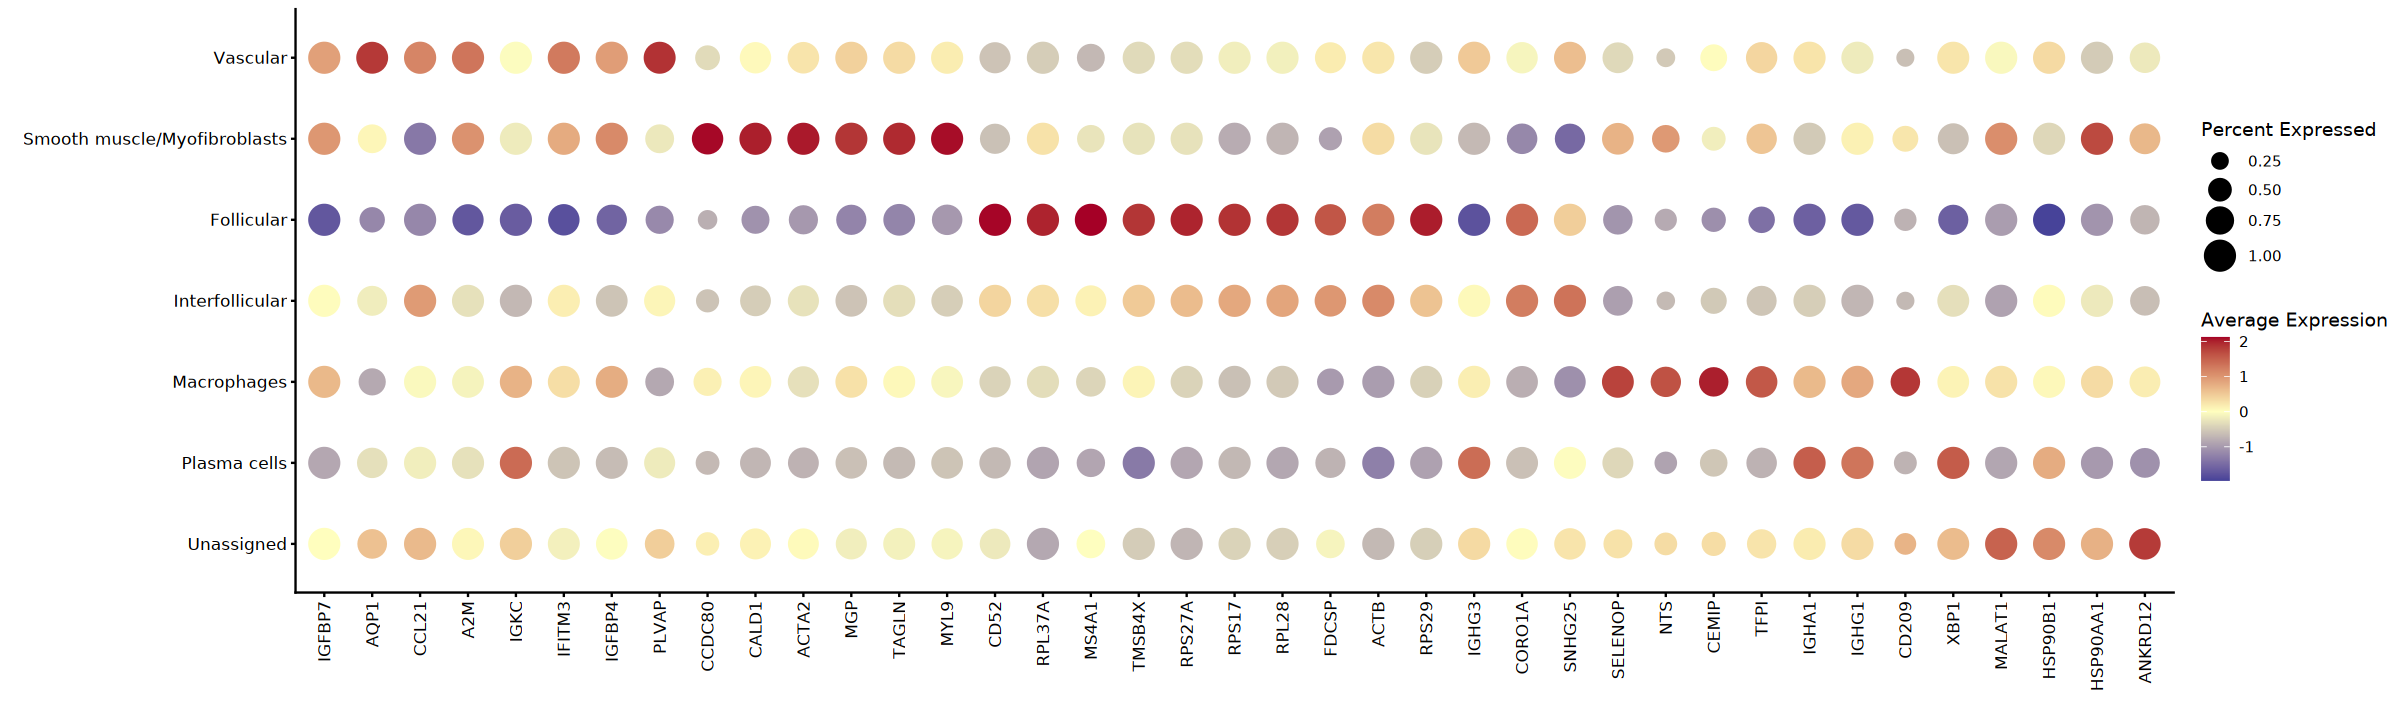

In [34]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

p <- dittoDotPlot(spe_dot, vars = gene_order, group.by = "annotation", size = 8, legend.size.title = "Percent Expressed") +  
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 10),
          axis.text.y = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold")) +
    labs(y = "", x = "") +
    scale_color_gradient2(low = "#313695", mid = "#FFFFBF", high = "#A50026", midpoint = 0, name = "Average Expression") 
ggsave("out/plots/dotplot_annot_ln.svg", plot = p, device = svglite, width = 20, height = 6)
print(p)

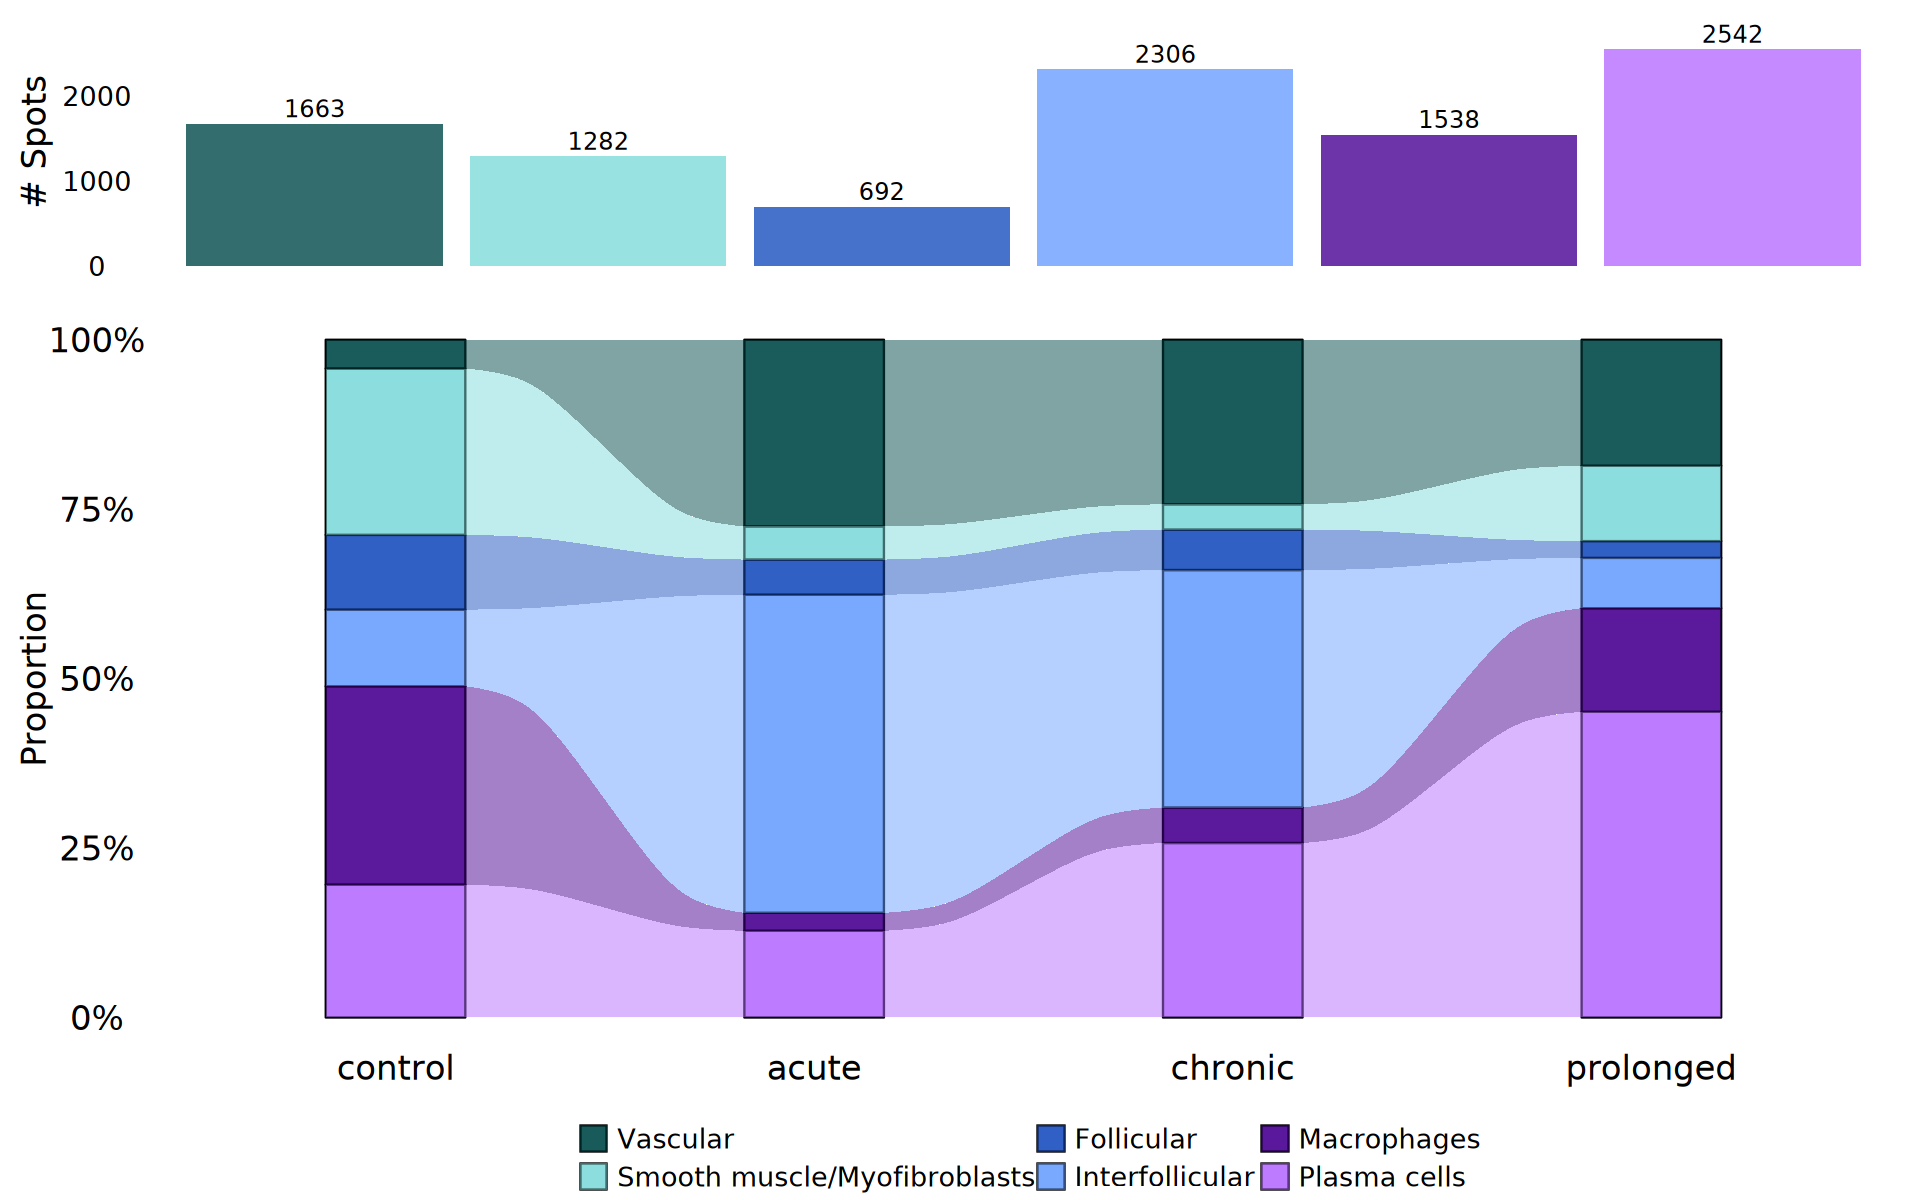

In [35]:
options(repr.plot.width = 16, repr.plot.height = 10, warn = -1)

palette <- c("Vascular" = "#004949", "Smooth muscle/Myofibroblasts" = "#80DADA", "Follicular" = "#1A4FBF",
             "Interfollicular" = "#6B9FFF", "Macrophages" = "#490092", "Plasma cells" = "#B66DFF",
             "Unassigned" = "#920000")
ct <- names(palette)  

p_top <- as.data.frame(colData(spe)) %>%
    filter(annotation != "Unassigned") %>%
    dplyr::count(annotation) %>%
    dplyr::arrange(match(annotation, ct)) %>%
    mutate(annotation = factor(annotation, levels = ct)) %>%
    ggplot(aes(x = annotation, y = n, fill = annotation)) +
    geom_bar(stat = "identity", alpha = 0.8) +
    geom_text(aes(label = n), vjust = -0.4, size = 5, color = "black") +
    labs(x = "", y = "# Spots") +
    scale_fill_manual(values = palette, guide = "none") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    theme_void() +
    theme(axis.text.y = element_text(color = "black", size = 16),
          axis.title = element_text(color = "black", size = 20),
          axis.title.y = element_text(angle = 90),
          plot.margin = margin(5, 5, 5, 5))

p_bottom <- as.data.frame(colData(spe)) %>%
    filter(annotation != "Unassigned") %>%
    mutate(disease_group = factor(disease_group,
                                  levels = c("control", "acute", "chronic", "prolonged"))) %>%
    dplyr::count(disease_group, annotation) %>%
    dplyr::group_by(disease_group) %>%
    dplyr::mutate(prop = n / sum(n)) %>%
    dplyr::ungroup() %>%
    mutate(annotation = factor(annotation, levels = ct)) %>%
    ggplot(aes(x = disease_group, y = prop, fill = annotation,
               alluvium = annotation, stratum = annotation)) +
    ggalluvial::geom_stratum(alpha = 0.8) +
    ggalluvial::geom_alluvium(alpha = 0.5) +
    labs(x = "", y = "Proportion") +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = palette, name = "") +
    theme_void() +
    theme(axis.text = element_text(color = "black", size = 20),
          axis.title = element_text(color = "black", size = 20),
          axis.title.y = element_text(angle = 90),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.position = "bottom")

p <- p_top / p_bottom + patchwork::plot_layout(heights = c(1, 3))

ggsave("out/plots/barplot_stage_ln_n.svg", plot = p, device = svglite, width = 20, height = 10)
print(p)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


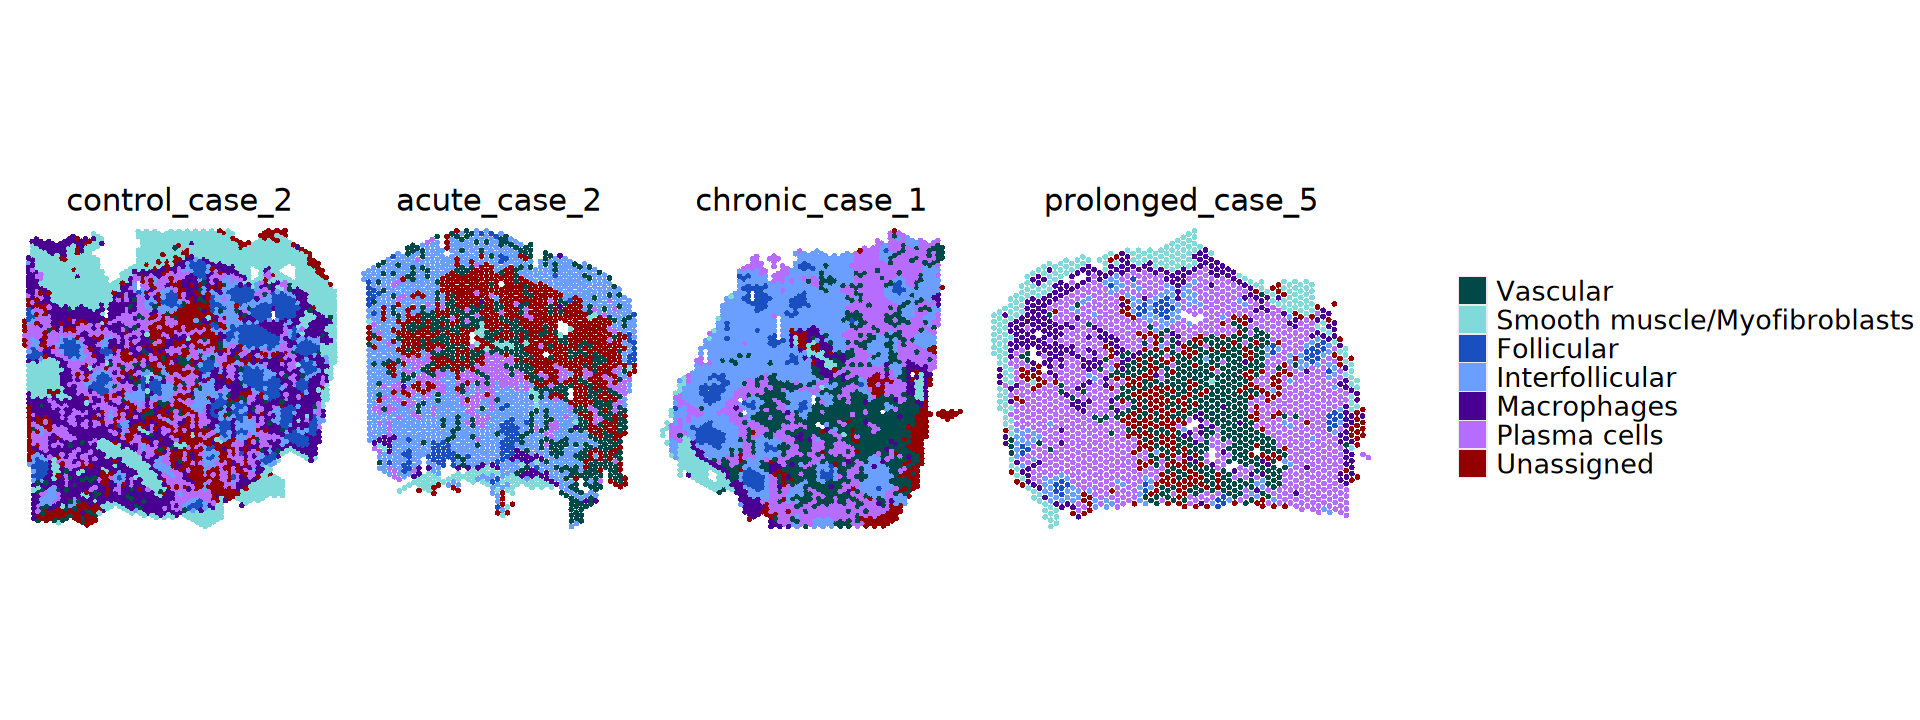

In [36]:
options(repr.plot.width = 16, repr.plot.height = 6, warn = -1)

plots <- lapply(unique(spe$study_id), function(id){
    sub <- spe[, spe$study_id == id]
    plotCoords(sub, annotate = "annotation", point_size = 1) +
        scale_color_manual(values = palette, drop = FALSE) + 
        coord_fixed() + 
        ggtitle(id) +
        theme_void() +
        theme(legend.position = "none",
              plot.title = element_text(hjust = 0.5, size = 18)) 
})


legend_plot <- ggplot(
    data.frame(ct = factor(ct, levels = ct), x = 1, y = seq_along(ct)),
    aes(x, y, fill = ct)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
    theme(legend.position = "right",
          legend.background = element_blank(),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.key = element_rect(color = NA)) +
    guides(fill = guide_legend(ncol = 1))
legend <- cowplot::get_legend(legend_plot)

p <- cowplot::plot_grid(
    wrap_plots(plots, ncol = 4),
    legend,
    ncol = 2,
    rel_widths = c(8, 3))

ggsave("out/plots/spatial_domains_ln.svg", plot = p, device = svglite, width = 16, height = 14)
print(p)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

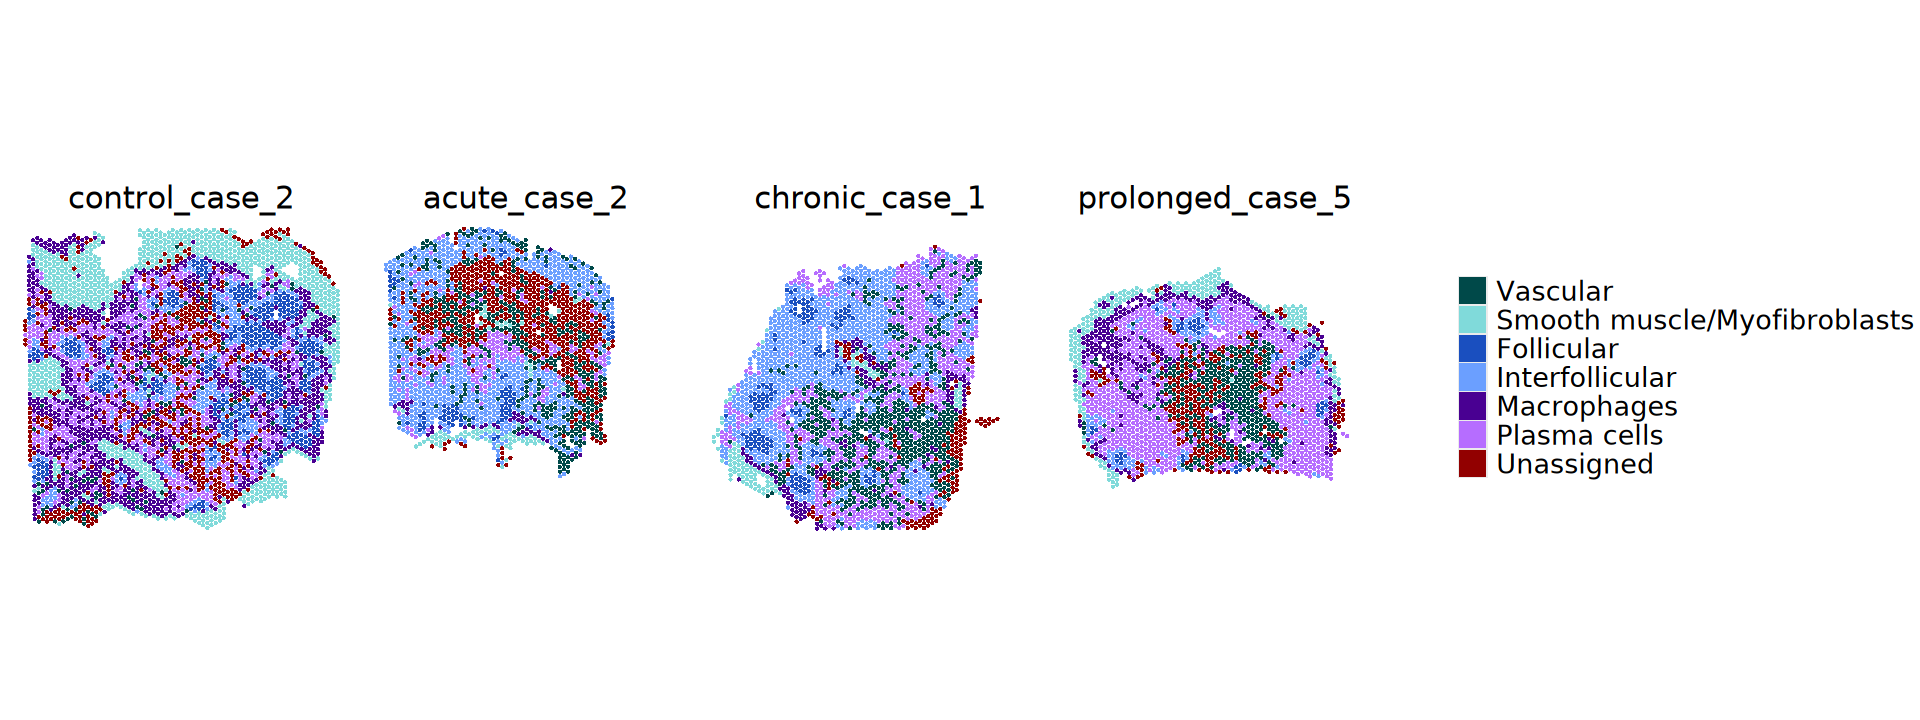

In [37]:
options(repr.plot.width = 16, repr.plot.height = 6, warn = -1)

plots <- lapply(unique(spe$study_id), function(id){
    sub <- spe[, spe$study_id == id]
    plotCoords(sub, annotate = "annotation", point_size = 0.6) +
        scale_color_manual(values = palette, drop = FALSE) + 
        coord_fixed() + 
        ggplot2::xlim(global_x_min, global_x_max) + 
        ggplot2::ylim(global_y_max, global_y_min) + 
        ggtitle(id) +
        theme_void() +
        theme(legend.position = "none",
              plot.title = element_text(hjust = 0.5, size = 18)) 
})


legend_plot <- ggplot(
    data.frame(ct = factor(ct, levels = ct), x = 1, y = seq_along(ct)),
    aes(x, y, fill = ct)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
    theme(legend.position = "right",
          legend.background = element_blank(),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.key = element_rect(color = NA)) +
    guides(fill = guide_legend(ncol = 1))
legend <- cowplot::get_legend(legend_plot)

p <- cowplot::plot_grid(
    wrap_plots(plots, ncol = 4),
    legend,
    ncol = 2,
    rel_widths = c(8, 3))

ggsave("out/plots/spatial_domains_ln_coords.svg", plot = p, device = svglite, width = 16, height = 14)
print(p)

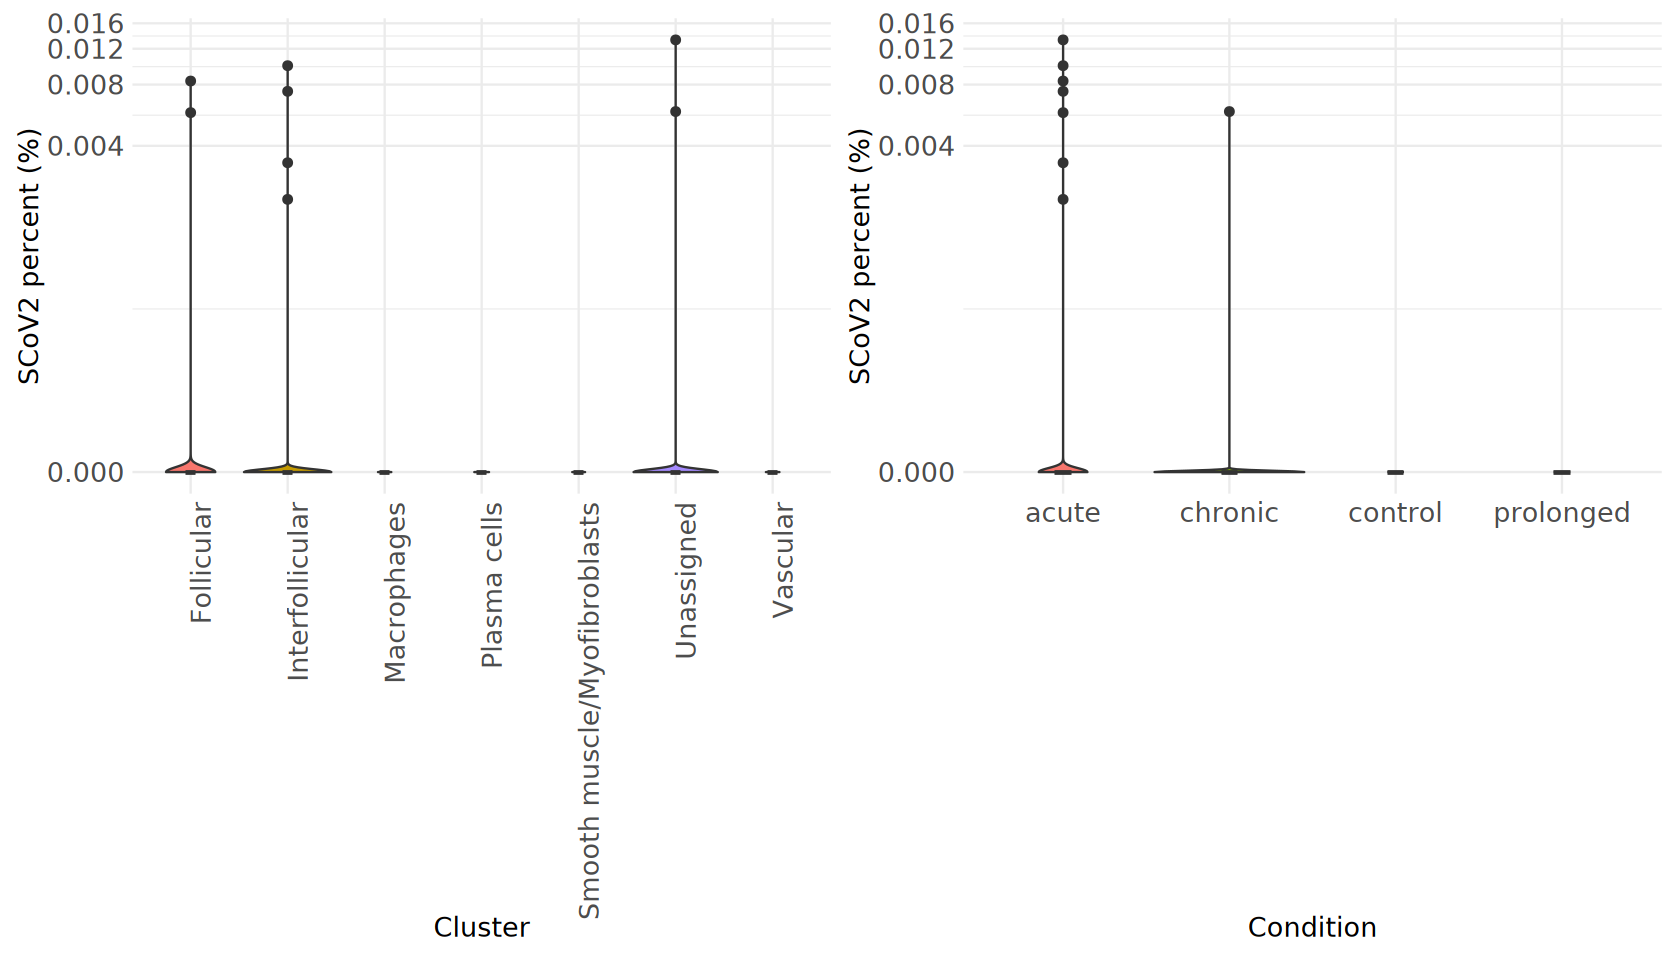

In [38]:
options(repr.plot.width = 14, repr.plot.height = 8, warn = -1)

p1 <- data.frame(cluster = colData(spe)$annotation, SCoV2_percent = colData(spe)$subsets_SCoV2_percent) %>%
    ggplot(aes(x = cluster, y = SCoV2_percent, fill = cluster)) +
    geom_violin(trim = TRUE) +
    geom_boxplot(width = 0.1, fill = "white", outlier.size = 2) +
    scale_y_continuous(trans = scales::pseudo_log_trans(sigma = 1e-04)) +
    labs(x = "Cluster", y = "SCoV2 percent (%)") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 16),
          axis.text.y = element_text(size = 16),
          axis.title.x = element_text(size = 16),
          axis.title.y = element_text(size = 16),
          legend.position = "none")

p2 <- data.frame(condition = colData(spe)$disease_group, SCoV2_percent = colData(spe)$subsets_SCoV2_percent) %>%
    ggplot(aes(x = condition, y = SCoV2_percent, fill = condition)) +
    geom_violin(trim = TRUE) +
    geom_boxplot(width = 0.1, fill = "white", outlier.size = 2) +
    scale_y_continuous(trans = scales::pseudo_log_trans(sigma = 1e-04)) +
    labs(x = "Condition", y = "SCoV2 percent (%)") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 0, hjust = 0.5, size = 16),
          axis.text.y = element_text(size = 16),
          axis.title.x = element_text(size = 16),
          axis.title.y = element_text(size = 16),
          legend.position = "none")

p1|p2

## Save data

In [39]:
remove <- grep("^Leiden_res_", names(colData(spe)), value = TRUE)
colData(spe) <- colData(spe)[, !names(colData(spe)) %in% remove]

saveHDF5SummarizedExperiment(spe, replace = TRUE, dir = "out/3-annot_ln_spe" %>%
                               glue::glue() %>%
                               here::here())

## Session information

In [40]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] svglite_2.2.2               scater_1.38.0              
 [3] dittoSeq_1.22.0             lisi_1.0                   
 [5] pheatmap_1.0.13             ggspavis_1.16.0            
 [7] igraph_2.